In [43]:
#імпорт необхідних бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

In [44]:
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

# Налаштування клієнту біг квері
project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

# SQL-запит для створення деталізованого датасету
query = """
   SELECT  s.date as date
   , s.ga_session_id as session_id
   , sp.continent as continent
   , sp.country as country
   , sp.device as device
   , sp.browser as browser
   , sp.mobile_model_name as mobile_model_name
   , sp.operating_system as operating_system
   , sp.language as language
   , sp.channel as channel
   , a.id as account_id
   , a.is_verified as is_verified
   , a.is_unsubscribed as is_unsubscribed
   , p.category as category
   , p.name as name_item
   , p.price as price
   , p.short_description as short_description
FROM `DA.session` s
LEFT JOIN  `DA.session_params` sp
ON s.ga_session_id=sp.ga_session_id
LEFT JOIN `DA.account_session` ase
ON s.ga_session_id=ase.ga_session_id
LEFT JOIN `DA.account` a
ON ase.account_id = a.id
LEFT JOIN `DA.order` o
ON s.ga_session_id=o.ga_session_id
LEFT JOIN  `DA.product` p
ON o.item_id=p.item_id
"""
# Завантаження даних у Pandas DataFrame
df = client.query(query).to_dataframe(create_bqstorage_client=False)
print(df.head())

         date  session_id continent         country   device browser  \
0  2020-11-01  5760483956  Americas   United States  desktop  Chrome   
1  2020-11-01  7115337200    Europe  United Kingdom  desktop  Chrome   
2  2020-11-01  3978035233    Europe          Norway   mobile  Chrome   
3  2020-11-01  9648986282    Africa         Nigeria   mobile  Chrome   
4  2020-11-01  4393441533      Asia           China  desktop  Chrome   

  mobile_model_name operating_system language         channel  account_id  \
0            Safari        Macintosh       zh     Paid Search        <NA>   
1            Chrome              Web    en-us  Organic Search        <NA>   
2           <Other>              Web       zh          Direct        <NA>   
3           <Other>          Android    es-es          Direct        <NA>   
4            Chrome          Windows    en-us          Direct        <NA>   

   is_verified  is_unsubscribed                    category name_item  price  \
0         <NA>          

#**Data overview**


**У датасеті міститься інформація щодо продажів продукції компанії, яка працює на світовому ринку і продає товари у інтернет-магазинах.**

**Датасет складається з таких колонок:**



    session_id - ідентифікатор сессії

    continent - назва континенту

    country - назва країни

    device - назва девайсу

    browser - назва браузера

    mobile_model_name  - назва моделі пристрою

    operating_system - операційна система

    language - мова браузеру

    channel - канал трафіку

    account_id - ідентифікатор зареєстрованого користувача

    is_verified - чи підтвердив користувач свій email

    is_unsubscribed - чи відписався користувач від розсилки
  
    date - дата

    category - категорія товару

    name_item - назва товару

    price - ціна

    short_description - короткий опис товару


In [45]:
# Загальна інформація
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               349545 non-null  dbdate 
 1   session_id         349545 non-null  Int64  
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   channel            349545 non-null  object 
 10  account_id         27945 non-null   Int64  
 11  is_verified        27945 non-null   Int64  
 12  is_unsubscribed    27945 non-null   Int64  
 13  category           33538 non-null   object 
 14  name_item          33538 non-null   object 
 15  price              33538 non-null   float64
 16  sh

In [46]:
# Базова статистика числових стовпців
df.describe()

,session_id,account_id,is_verified,is_unsubscribed,price
count,349545.0,27945.0,27945.0,27945.0,33538.000000
mean,4992250296.631739,659005.065557,0.71698,0.16944,953.298679
std,2887450949.537772,13216.529465,0.450474,0.375147,1317.001775
min,1205.0,636133.0,0.0,0.0,3.000000
25%,2493646855.0,647576.0,0.0,0.0,170.000000
50%,4988476074.0,658952.0,1.0,0.0,445.000000
75%,7491286508.0,670414.0,1.0,0.0,1195.000000
max,9999997129.0,681962.0,1.0,1.0,9585.000000


#**Data cleaning**

In [47]:
# Порахувати кількість пропусків у кожному стовпці
print("Кількість пропусків:")
print(df.isna().sum())

# Порахувати відсоток пропусків (дуже корисно для бізнес-звітів)
print("\nВідсоток пропусків (%):")
print((df.isna().sum() / len(df)) * 100)

Кількість пропусків:
date                      0
session_id                0
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
channel                   0
account_id           321600
is_verified          321600
is_unsubscribed      321600
category             316007
name_item            316007
price                316007
short_description    316007
dtype: int64

Відсоток пропусків (%):
date                  0.000000
session_id            0.000000
continent             0.000000
country               0.000000
device                0.000000
browser               0.000000
mobile_model_name     0.000000
operating_system      0.000000
language             32.689925
channel               0.000000
account_id           92.005321
is_verified          92.005321
is_unsubscribed      92.005321
category             90.405241
name_item            90.405241


Багато пропусків через те,що частина користувачів не авторизовані

In [48]:
#  Заповнення порожніх значень
df['language'] = df['language'].fillna('Unknown')
product_text_cols = ['category', 'name_item', 'short_description']
df[product_text_cols] = df[product_text_cols].fillna('No Purchase')
df['price'] = df['price'].fillna(0.0)

df['is_verified'] = df['is_verified'].fillna(0)
df['is_unsubscribed'] = df['is_unsubscribed'].fillna(0)

In [49]:
# Пошук дублікатів

df.duplicated().sum()

np.int64(0)

In [50]:
# Перетворення данних у датасеті, щоб кожне слово починалося з великої літери
df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").apply(lambda x: x.str.title())
# Перетворення у формат дата час
df['date']=pd.to_datetime(df['date'])

In [51]:
# Oгляд датасету
df.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,language,channel,account_id,is_verified,is_unsubscribed,category,name_item,price,short_description
0,2020-11-01,5760483956,Americas,United States,Desktop,Chrome,Safari,Macintosh,Zh,Paid Search,<NA>,0,0,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
1,2020-11-01,7115337200,Europe,United Kingdom,Desktop,Chrome,Chrome,Web,En-Us,Organic Search,<NA>,0,0,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
2,2020-11-01,3978035233,Europe,Norway,Mobile,Chrome,<Other>,Web,Zh,Direct,<NA>,0,0,Tables & Desks,Råskog,189.0,"Trolley, 35X45X78 Cm"
3,2020-11-01,9648986282,Africa,Nigeria,Mobile,Chrome,<Other>,Android,Es-Es,Direct,<NA>,0,0,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"
4,2020-11-01,4393441533,Asia,China,Desktop,Chrome,Chrome,Windows,En-Us,Direct,<NA>,0,0,Bookcases & Shelving Units,Vittsjö,609.0,"Shelving Unit With Laptop Table, 202X36X175 Cm"


In [52]:

# Загальна кількість колонок
total_columns = df.shape[1]

# Числові колонки (int, float)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

# Категоріальні/текстові колонки
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# Колонки типу datetime
datetime_cols = df.select_dtypes(include=['datetime64', 'datetimetz']).columns.tolist()

# Кількість унікальних сесій
unique_sessions = df['session_id'].nunique()

# Період часу (від... до...)
min_date = df['date'].min().strftime('%Y-%m-%d')
max_date = df['date'].max().strftime('%Y-%m-%d')

# Кількість країн
country_count = df['country'].nunique()

# Загальна виручка
sum_price = df['price'].sum()

# Кількість замовлень
# Фільтруємо лише сесії, де відбувся продаж
sales_df = df[df['price'] > 0]


# Кількість проданого товару
total_item = sales_df['name_item'].count()


# Перевірка наявності пропусків та їх відсоток
has_missing = df.isna().any().any()
missing_summary = pd.DataFrame({
    'count': df.isna().sum(),
    'percent': (df.isna().mean() * 100).round(2)
}).query('count > 0').sort_values(by='count', ascending=False)


# Відфільтровуємо лише зареєстрованих користувачів (ігноруємо незареєстрованих гостей)
accounts_df = df[df['account_id'].notna()]

# Підраховуємо кількість верифікованих та загальну кількість акаунтів
total_accounts = len(accounts_df)
verified_accounts = (accounts_df['is_verified'] == 1).sum()

# Вираховуємо відсоток
verified_pct = (verified_accounts / total_accounts) * 100

# Підраховуємо загальну кількість акаунтів та відписаних користувачів
total_accounts = len(accounts_df)
unsubscribed_accounts = (accounts_df['is_unsubscribed'] == 1).sum()

# Вираховуємо відсоткове співвідношення
unsubscribed_pct = (unsubscribed_accounts / total_accounts) * 100
subscribed_pct = 100 - unsubscribed_pct

# Вивід результатів
print(f"Загальна кількість колонок: {total_columns}\n")

print(f"Числові колонки ({len(numeric_cols)}): {numeric_cols}\n")

print(f"Категоріальні колонки ({len(categorical_cols)}): {categorical_cols}\n")

print(f"Datetime колонки ({len(datetime_cols)}): {datetime_cols}\n")

print(f"Кількість унікальних сесій: {unique_sessions}\n")

print(f"Період часу: від {min_date} до {max_date}\n")

print(f"Кылькість унікальних країн: {country_count}\n")

print(f"Загальна виручка: {sum_price}\n")

print(f"Кількість проданих товарів: {total_item}\n")


print(f"Чи є пропущені значення: {'Так' if has_missing else 'Ні'}\n")

print("Колонки з найбільшою кількістю пропусків:")

if missing_summary.empty:
    print("Пропущені значення відсутні.\n")
else:
    print(missing_summary)

print(f"Загалом унікальних акаунтів: {total_accounts}\n")

print(f"Підтвердили email: {verified_accounts}\n")

print(f"Відсоток верифікованих користувачів: {verified_pct:.2f}%\n")

print(f"Відписалися від розсилки: {unsubscribed_accounts} ({unsubscribed_pct:.2f}%)\n")

print(f"Залишаються підписаними: {total_accounts - unsubscribed_accounts} ({subscribed_pct:.2f}%)\n")

print(f"Мода по країнам: {df['country'].mode()}\n")

print(f"Мода по пристроям: {df['device'].mode()}\n")

print(f"Мода по браузерам: {df['browser'].mode()}\n")

print(f"Мода по операційній системі: {df['operating_system'].mode()}\n")

print(f"Мода по мові: {df['language'].mode()}\n")

print(f"Мода по категоріям: {df['category'].mode()}\n")

print(f"Мода по назві продукту: {df['name_item'].mode()}\n")


Загальна кількість колонок: 17

Числові колонки (5): ['session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'price']

Категоріальні колонки (11): ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'channel', 'category', 'name_item', 'short_description']

Datetime колонки (1): ['date']

Кількість унікальних сесій: 349545

Період часу: від 2020-11-01 до 2021-01-31

Кылькість унікальних країн: 108

Загальна виручка: 31971731.100000005

Кількість проданих товарів: 33538

Чи є пропущені значення: Так

Колонки з найбільшою кількістю пропусків:
             count  percent
account_id  321600    92.01
Загалом унікальних акаунтів: 27945

Підтвердили email: 20036

Відсоток верифікованих користувачів: 71.70%

Відписалися від розсилки: 4735 (16.94%)

Залишаються підписаними: 23210 (83.06%)

Мода по країнам: 0    United States
Name: country, dtype: object

Мода по пристроям: 0    Desktop
Name: device, dtype: object

Мода по браузерам: 0    Chro

In [53]:
# Збереження у csv формат
df.to_csv('df_analis.csv', index=False)

# Завантажуємо файл на свій комп'ютер через браузер
from google.colab import files
files.download('df_analis.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Data analysis and visualization**

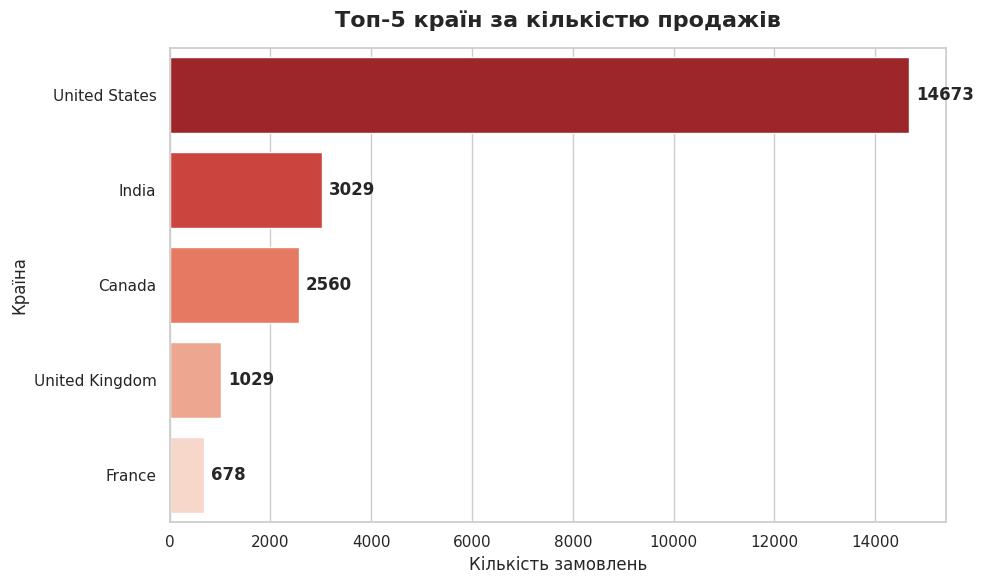

In [54]:

# Фільтруємо лише сесії, де відбувся продаж
sales_df = df[df['price'] > 0]

# Знаходимо Топ-5 країн за кількістю продажів
top5_countries = sales_df['country'].value_counts().head(5)

# Налаштовуємо стиль та розмір графіка
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Будуємо горизонтальний стовпчиковий графік
ax = sns.barplot(
    x=top5_countries.values,
    y=top5_countries.index,
    hue=top5_countries.index,
    palette="Reds_r",
    legend=False

)

# Додаємо підписи значень прямо на стовпчики
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontweight='bold')

# Оформлення заголовків та осей
plt.title('Топ-5 країн за кількістю продажів', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість замовлень', fontsize=12)
plt.ylabel('Країна', fontsize=12)


plt.tight_layout()
plt.show()

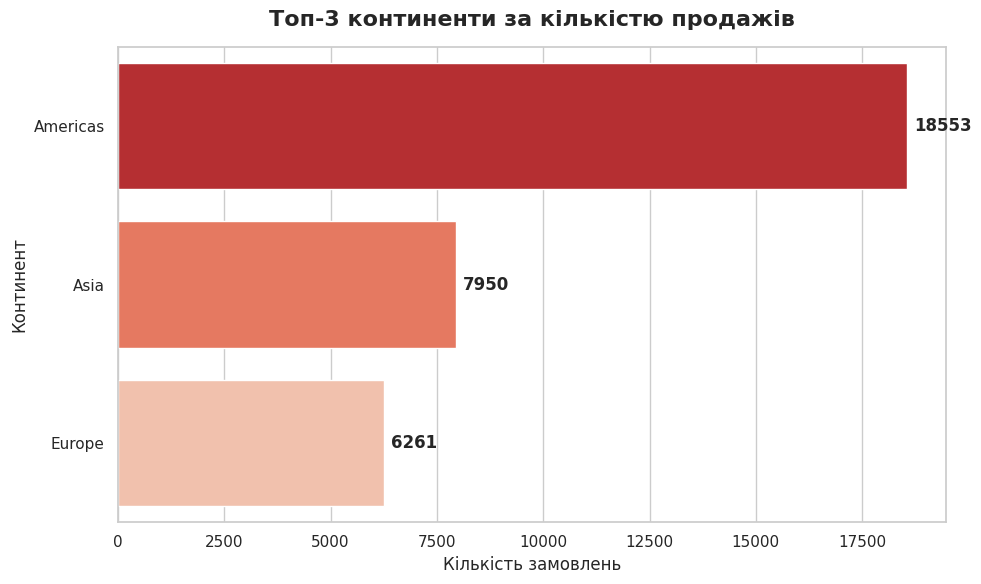

In [55]:
# Фільтруємо лише сесії із виконаними продажами (price > 0)
sales_df = df[df['price'] > 0].copy()

# Знаходимо Топ-3 континенти за кількістю продажів
top3_continent = sales_df['continent'].value_counts().head(3)

# Налаштовуємо стиль та розмір графіка
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Будуємо горизонтальний стовпчиковий графік
ax = sns.barplot(
    x=top3_continent.values,
    y=top3_continent.index,
    hue=top3_continent.index,
    palette="Reds_r",
    legend=False
)

# Додаємо підписи значень прямо на стовпчики
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontweight='bold')

# Оформлення заголовків та осей
plt.title('Топ-3 континенти за кількістю продажів', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Кількість замовлень', fontsize=12)
plt.ylabel('Континент', fontsize=12)


plt.tight_layout()
plt.show()

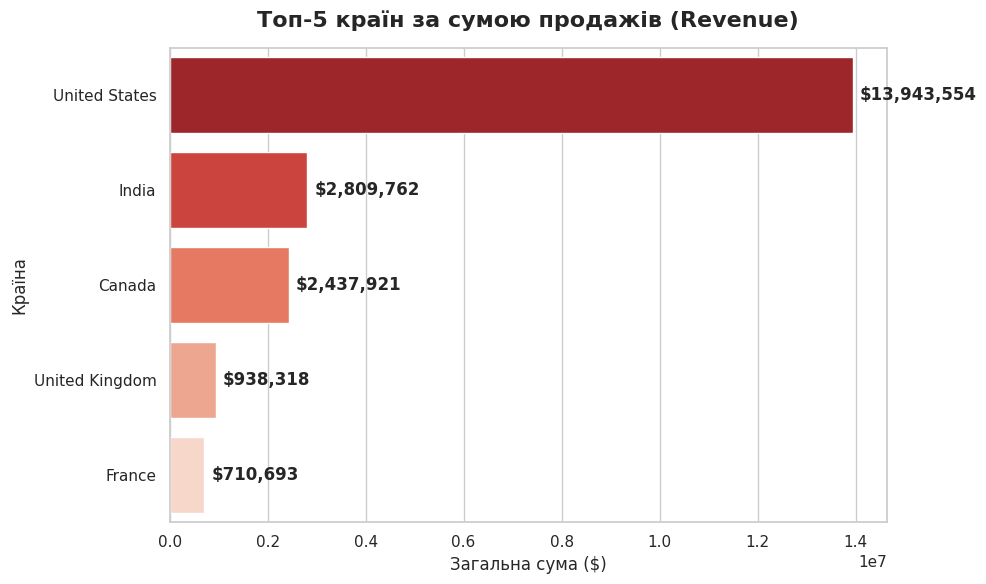

In [56]:
# Групуємо за країною, сумуємо 'price' та беремо Топ-5
top5_countries_revenue = (df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)
)

# Налаштування розміру та стилю
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Побудова горизонтального бар-чарту
ax = sns.barplot(
    x=top5_countries_revenue.values,
    y=top5_countries_revenue.index,
    hue=top5_countries_revenue.index,
    palette="Reds_r",
    legend=False
)

# Додаємо форматовані підписи суми прямо на стовпчики ($ / ₴ / тис.)
for container in ax.containers:
    # Форматуємо значення як грошову суму з розділювачами тисяч
    labels = [f"${val:,.0f}" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold')

# Заголовки та підписи осей
plt.title('Топ-5 країн за сумою продажів (Revenue)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Загальна сума ($)', fontsize=12)
plt.ylabel('Країна', fontsize=12)


plt.tight_layout()
plt.show()

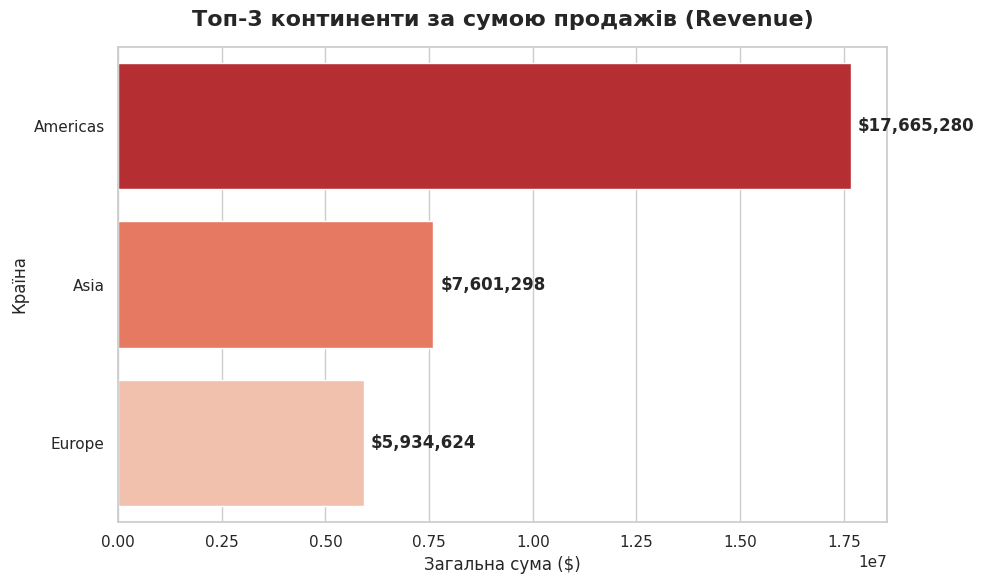

In [57]:
# Групуємо за континентом, сумуємо 'price' та беремо Топ-3
top3_continent_revenue = (df.groupby('continent')['price'].sum().sort_values(ascending=False).head(3)
)

# Налаштування розміру та стилю
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Побудова горизонтального бар-чарту
ax = sns.barplot(
    x=top3_continent_revenue.values,
    y=top3_continent_revenue.index,
    hue=top3_continent_revenue.index,
    palette="Reds_r",
    legend=False
)

# Додаємо форматовані підписи суми прямо на стовпчики ($ / ₴ / тис.)
for container in ax.containers:
    # Форматуємо значення як грошову суму з розділювачами тисяч
    labels = [f"${val:,.0f}" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold')

# Заголовки та підписи осей
plt.title('Топ-3 континенти за сумою продажів (Revenue)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Загальна сума ($)', fontsize=12)
plt.ylabel('Країна', fontsize=12)


plt.tight_layout()
plt.show()

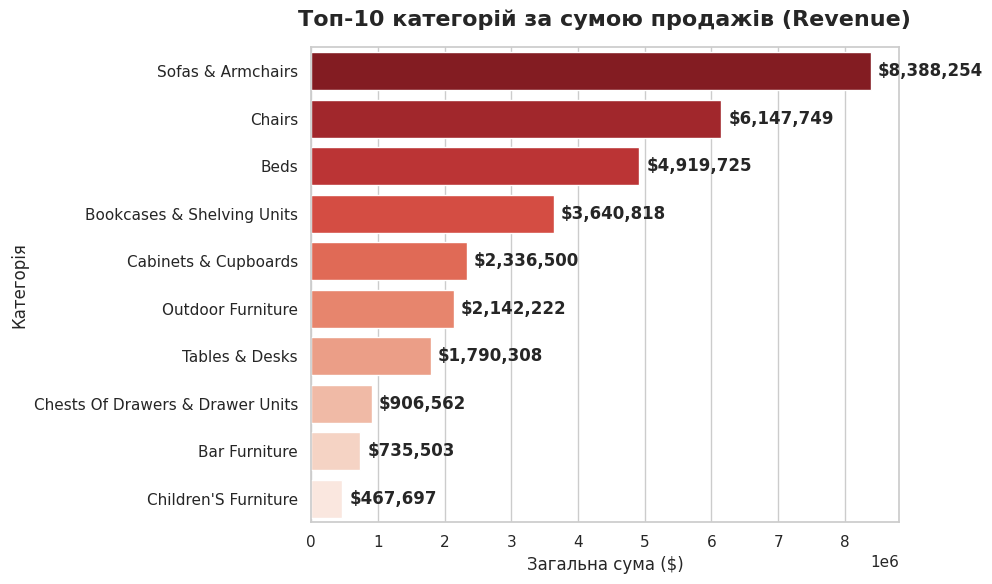

In [58]:
# Групуємо за категорією, сумуємо 'price' та беремо Топ-5
top10_category_revenue = (df.groupby('category')['price'].sum().sort_values(ascending=False).head(10)
)

# Налаштування розміру та стилю
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Побудова горизонтального бар-чарту
ax = sns.barplot(
    x=top10_category_revenue.values,
    y=top10_category_revenue.index,
    hue=top10_category_revenue.index,
    palette="Reds_r",
    legend=False
)

# Додаємо форматовані підписи суми прямо на стовпчики ($ / ₴ / тис.)
for container in ax.containers:
    # Форматуємо значення як грошову суму з розділювачами тисяч
    labels = [f"${val:,.0f}" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold')

# Заголовки та підписи осей
plt.title('Топ-10 категорій за сумою продажів (Revenue)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Загальна сума ($)', fontsize=12)
plt.ylabel('Категорія', fontsize=12)


plt.tight_layout()
plt.show()

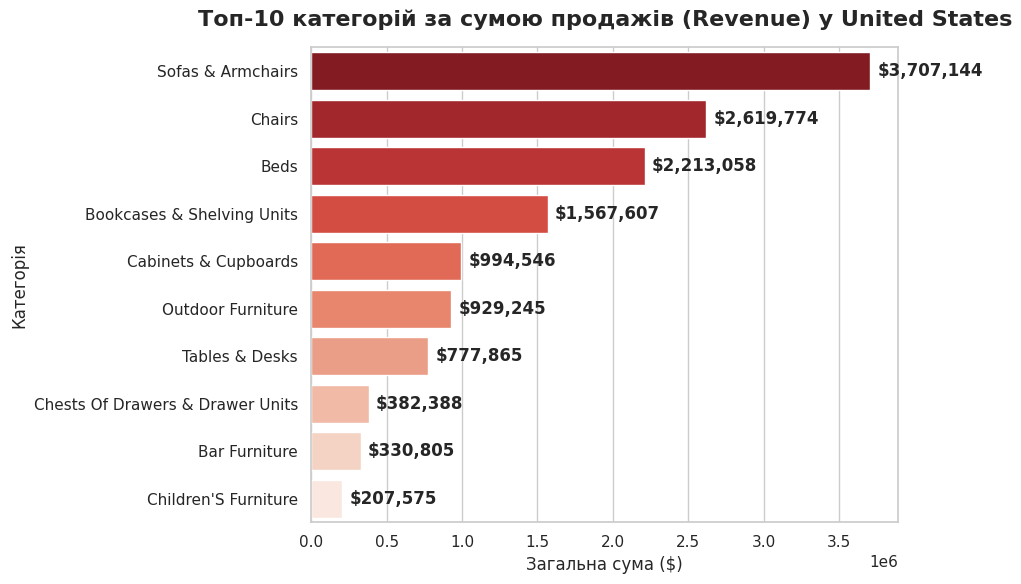

In [59]:
top1_country_revenue = (df.groupby('country')['price'].sum().sort_values(ascending=False).head(1))

# Отримуємо назву країни з найбільшим доходом
top_country_name = top1_country_revenue.index[0]

# Фільтруємо дані для цієї країни та групуємо за категорією
top10_category_revenue_top1_country = (df[df['country'] == top_country_name].groupby('category')['price'].sum().sort_values(ascending=False).head(10)
)

# Налаштування розміру та стилю
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Побудова горизонтального бар-чарту
ax = sns.barplot(
    x=top10_category_revenue_top1_country.values,
    y=top10_category_revenue_top1_country.index,
    hue=top10_category_revenue_top1_country.index,
    palette="Reds_r",
    legend=False
)

# Додаємо форматовані підписи суми прямо на стовпчики ($ / ₴ / тис.)
for container in ax.containers:
    # Форматуємо значення як грошову суму з розділювачами тисяч
    labels = [f"${val:,.0f}" for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontweight='bold')

# Заголовки та підписи осей
plt.title(f'Топ-10 категорій за сумою продажів (Revenue) у {top_country_name}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Загальна сума ($)', fontsize=12)
plt.ylabel('Категорія', fontsize=12)


plt.tight_layout()
plt.show()

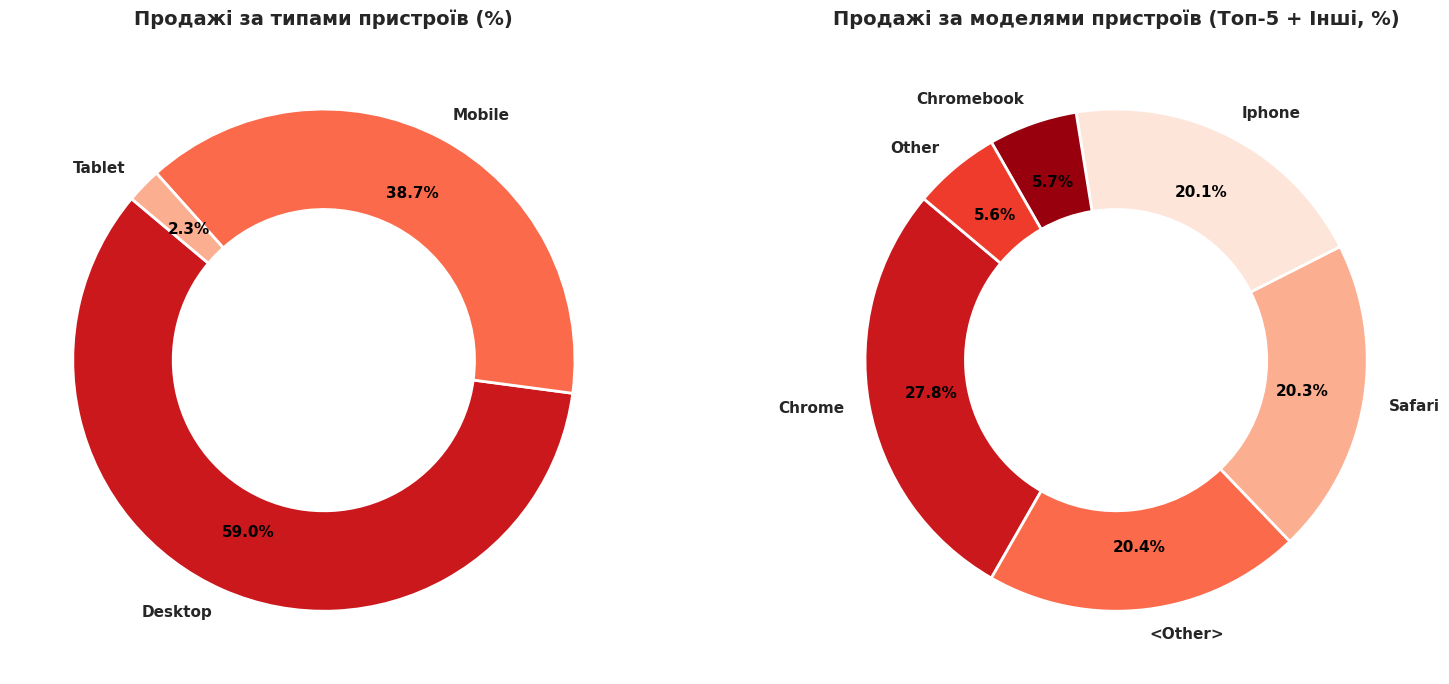

In [60]:
# Агрегуємо продажі за типом девайсу та за моделями
device_revenue = sales_df.groupby('device')['price'].sum()
model_revenue = sales_df.groupby('mobile_model_name')['price'].sum()

# Для моделей залишаємо ТОП-5, а інші об'єднаємо у 'Other', щоб графік не перевантажувався
top_models = model_revenue.nlargest(5)
other_models_sum = model_revenue.drop(top_models.index).sum()
if other_models_sum > 0:
    top_models['Other'] = other_models_sum

# Налаштування полотна для двох окремих графіків
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['#cb181d', '#fb6a4a', '#fcae91', '#fee5d9', '#99000d', '#ef3b2c']

# --- ДІАГРАМА 1: Продажі за типами девайсів ---
wedges1, texts1, autotexts1 = axes[0].pie(
    device_revenue,
    labels=device_revenue.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(device_revenue)],
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[0].set_title('Продажі за типами пристроїв (%)', fontsize=14, fontweight='bold', pad=15)

# --- ДІАГРАМА 2: Продажі за моделями пристроїв ---
wedges2, texts2, autotexts2 = axes[1].pie(
    top_models,
    labels=top_models.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors[:len(top_models)],
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)
axes[1].set_title('Продажі за моделями пристроїв (Топ-5 + Інші, %)', fontsize=14, fontweight='bold', pad=15)

# Налаштування кольору відсотків всередині кілець
for autotext in autotexts1 + autotexts2:
    autotext.set_color('black')

sns.despine()
plt.tight_layout()
plt.show()

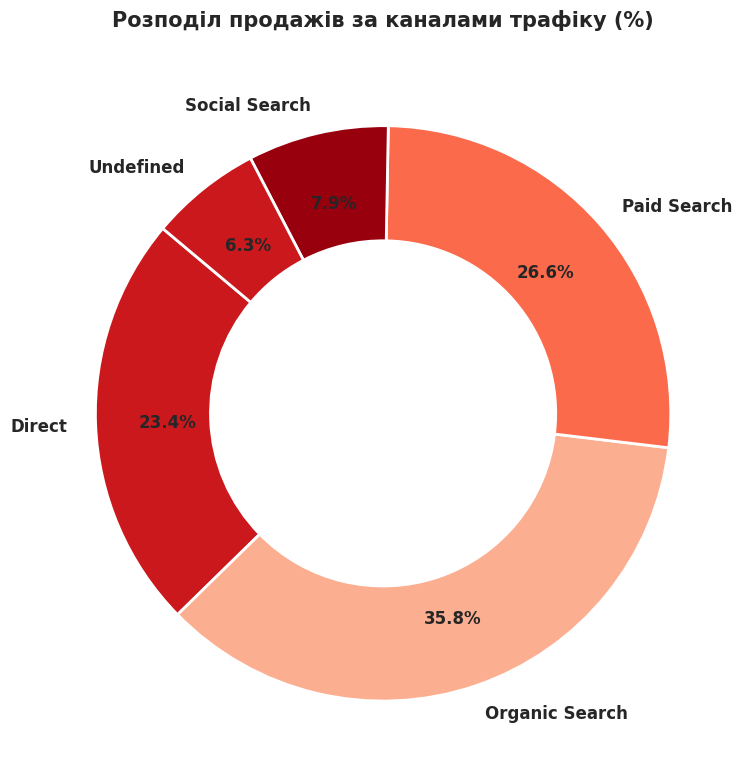

In [61]:
# Сума продажів за джерелом трафіку
device_revenue = sales_df.groupby('channel')['price'].sum()

# Побудова  Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#cb181d', '#fcae91', '#fb6a4a', '#99000d']

wedges, texts, autotexts = ax.pie(
    device_revenue,
    labels=device_revenue.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Розподіл продажів за каналами трафіку (%)', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

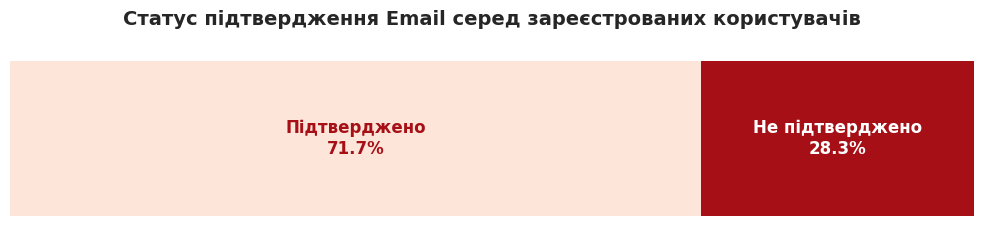

In [62]:
# Розрахунок відсотків
verified_pct = (verified_accounts / total_accounts) * 100
unverified_pct = 100 - verified_pct

fig, ax = plt.subplots(figsize=(10, 2.5))

# Побудова фонової (червоної для "Не підтверджено") та основної (білої для "Підтверджено") смуги
ax.barh(['Email Verification'], [100], color='#a50f15', edgecolor='none', height=0.5)
# Draw the 'Підтверджено' section on top in white/light color
ax.barh(['Email Verification'], [verified_pct], color='#fee5d9', edgecolor='none', height=0.5)


# Додавання текстових підписів всередину смуг
ax.text(verified_pct / 2, 0, f'Підтверджено\n{verified_pct:.1f}%',
        va='center', ha='center', color='#a50f15', fontweight='bold', fontsize=12)

ax.text(verified_pct + (unverified_pct / 2), 0, f'Не підтверджено\n{unverified_pct:.1f}%',
        va='center', ha='center', color='white', fontweight='bold', fontsize=12)

# Оформлення та приховування зайвих осей
ax.set_xlim(0, 100)
ax.axis('off')
plt.title('Статус підтвердження Email серед зареєстрованих користувачів',
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

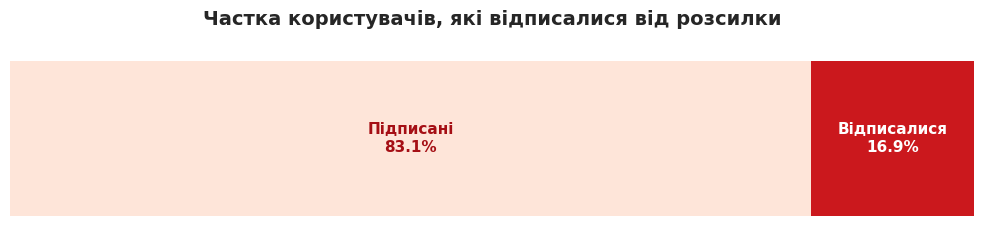

In [63]:
fig, ax = plt.subplots(figsize=(10, 2.5))

# Побудова смуги для 'Підписані'
ax.barh(['Newsletter Status'], [subscribed_pct], color='#fee5d9', edgecolor='none', height=0.5)
# Побудова смуги для 'Відписалися'
ax.barh(['Newsletter Status'], [unsubscribed_pct], left=subscribed_pct, color='#cb181d', edgecolor='none', height=0.5)

# Підписи відсотків усередині смуг
ax.text(subscribed_pct / 2, 0, f'Підписані\n{subscribed_pct:.1f}%',
        va='center', ha='center', color='#a50f15', fontweight='bold', fontsize=11)

ax.text(subscribed_pct + (unsubscribed_pct / 2), 0, f'Відписалися\n{unsubscribed_pct:.1f}%',
        va='center', ha='center', color='white', fontweight='bold', fontsize=11)

# Приховування осей для чистоти дизайну
ax.set_xlim(0, 100)
ax.axis('off')
plt.title('Частка користувачів, які відписалися від розсилки',
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

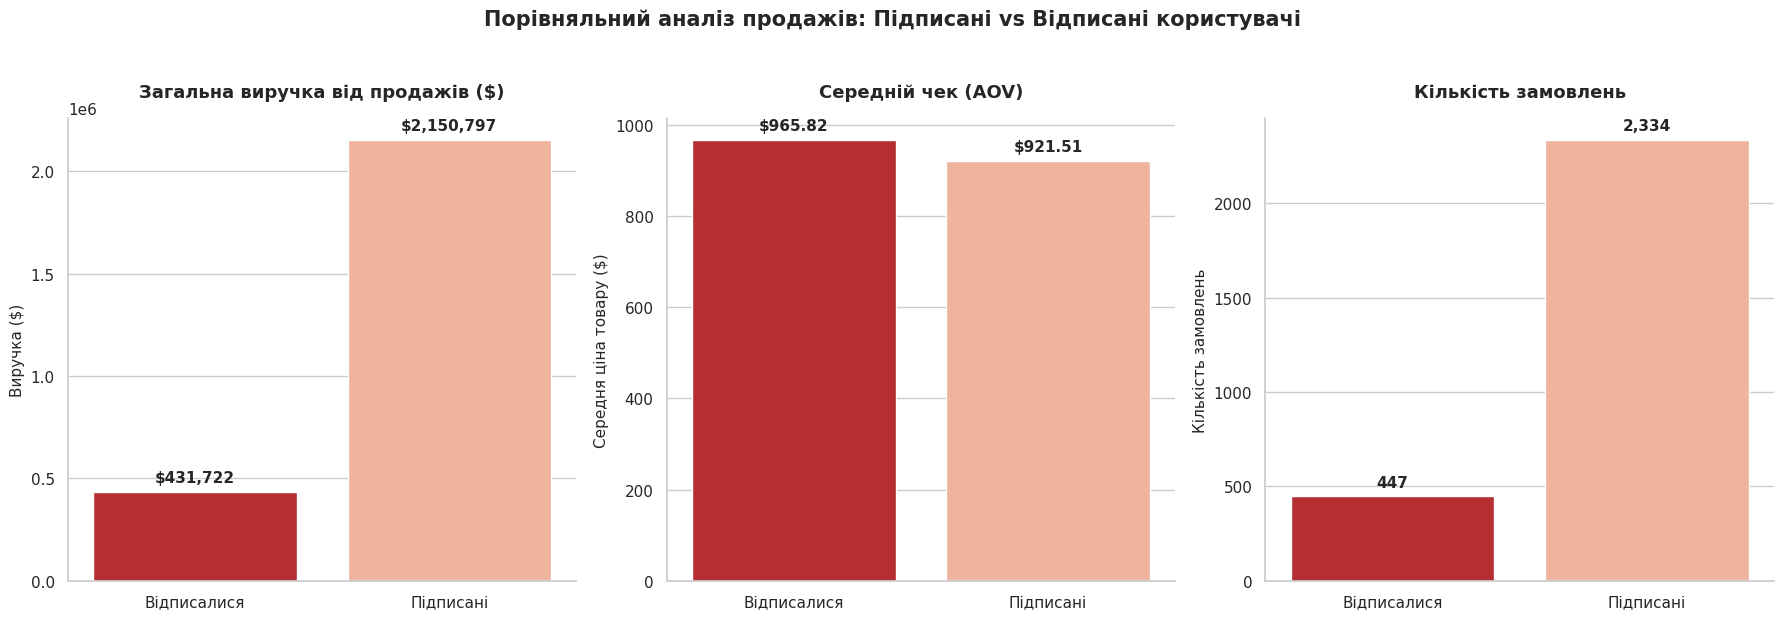

In [64]:

# Відфільтровуємо лише зареєстрованих користувачів та здійснені покупки
sales_df = df[(df['account_id'].notna()) & (df['price'] > 0)].copy()

# Створюємо текстовий статус підписки
sales_df['subscription_status'] = sales_df['is_unsubscribed'].apply(
    lambda x: 'Відписалися' if x == 1 else 'Підписані'
)

# Агрегуємо показники продажів: загальна виручка та середній чек
metrics_df = sales_df.groupby('subscription_status').agg(
    total_revenue=('price', 'sum'),
    avg_order_value=('price', 'mean'),
    total_orders=('price', 'count')
).reset_index()

# Налаштування полотна для трьох порівняльних графіків
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")
palette = {'Відписалися': '#cb181d', 'Підписані': '#fcae91'}

# --- ГРАФІК 1: Загальна виручка ---
ax1 = sns.barplot(
    data=metrics_df,
    x='subscription_status',
    y='total_revenue',
    hue='subscription_status',
    palette=palette,
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Загальна виручка від продажів ($)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_ylabel('Виручка ($)', fontsize=11)
axes[0].set_xlabel('')

# Підписи значень на стовпчиках 1
for p in ax1.patches:
    val = p.get_height()
    ax1.annotate(f'${val:,.0f}',
                 (p.get_x() + p.get_width() / 2., val),
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 xytext=(0, 5), textcoords='offset points')

# --- ГРАФІК 2: Середній чек (AOV) ---
ax2 = sns.barplot(
    data=metrics_df,
    x='subscription_status',
    y='avg_order_value',
    hue='subscription_status',
    palette=palette,
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Середній чек (AOV)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_ylabel('Середня ціна товару ($)', fontsize=11)
axes[1].set_xlabel('')

# Підписи значень на стовпчиках 2
for p in ax2.patches:
    val = p.get_height()
    ax2.annotate(f'${val:,.2f}',
                 (p.get_x() + p.get_width() / 2., val),
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 xytext=(0, 5), textcoords='offset points')


# --- ГРАФІК 3: Кількість замовлень ---
ax3 = sns.barplot(
    data=metrics_df,
    x='subscription_status',
    y='total_orders',
    hue='subscription_status',
    palette=palette,
    legend=False,
    ax=axes[2]
)
axes[2].set_title('Кількість замовлень', fontsize=13, fontweight='bold', pad=15)
axes[2].set_ylabel('Кількість замовлень', fontsize=11)
axes[2].set_xlabel('')

# Підписи значень на стовпчиках 3
for p in ax3.patches:
    val = p.get_height()
    ax3.annotate(f'{val:,.0f}',
                 (p.get_x() + p.get_width() / 2., val),
                 ha='center', va='bottom', fontsize=11, fontweight='bold',
                 xytext=(0, 5), textcoords='offset points')
# Загальне оформлення
sns.despine()
plt.suptitle('Порівняльний аналіз продажів: Підписані vs Відписані користувачі',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Загальна виручка** : Підписані користувачі генерують у ~5 разів більше загальної виручки, ніж ті, хто відписався. Вони є головним джерелом прибутку для бізнесу.

**Середній чек** : Середній чек у двох груп майже однаковий, але у користувачів, які відписалися, він навіть трохи вищий (~$44 різниці або ~4.8%). Це свідчить про те, що факт відписки від розсилки практично не впливає на готовність купувати товари аналогічної вартості або платити за одноразову покупку.


**Кількість замовлень**: Підписані користувачі роблять у ~5.2 раза більше замовлень, можливо це через те,що  регулярно отримують маркетингові нагадування, акції та спеціальні пропозиції через email.

/tmp/ipykernel_1114/3895056542.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


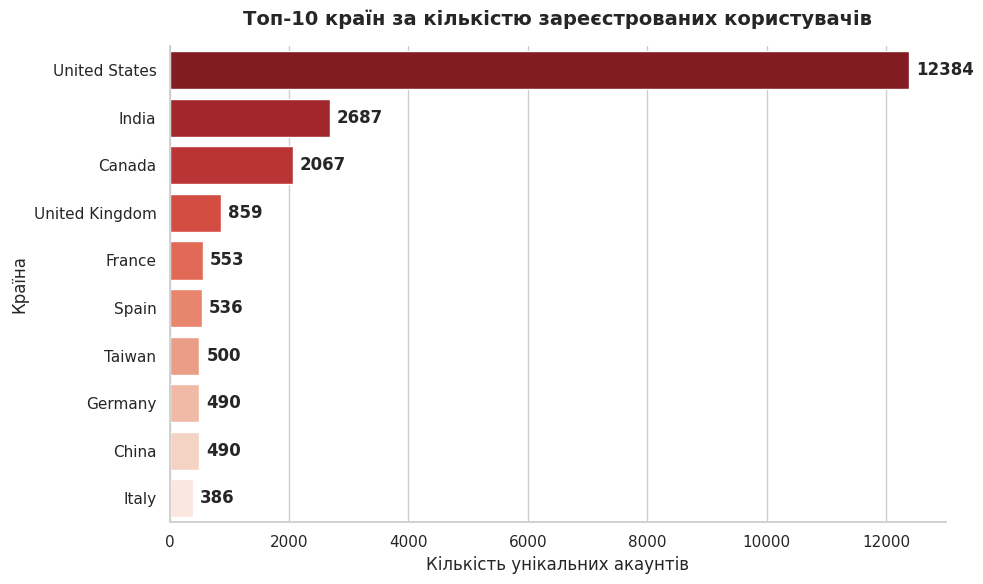

In [65]:
# Відфільтровуємо лише зареєстрованих користувачів та прибираємо повтори акаунтів
registered_users_df = df[df['account_id'].notna()].drop_duplicates('account_id')

# Рахуємо кількість унікальних користувачів для кожної країни та беремо Топ-10
top_countries = registered_users_df['country'].value_counts().head(10)

# Налаштовуємо графік
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Побудова горизонтального стовпчикового графіка (Bar Chart)
ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="Reds_r"
)

# Додаємо точні підписи кількості акаунтів прямо на стовпчики
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontweight='bold')

# Заголовки та підписи осей
plt.title('Топ-10 країн за кількістю зареєстрованих користувачів', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кількість унікальних акаунтів', fontsize=12)
plt.ylabel('Країна', fontsize=12)

# Прибираємо зайві рамки
sns.despine()

plt.tight_layout()
plt.show()


#**Аналіз динаміки продажів**

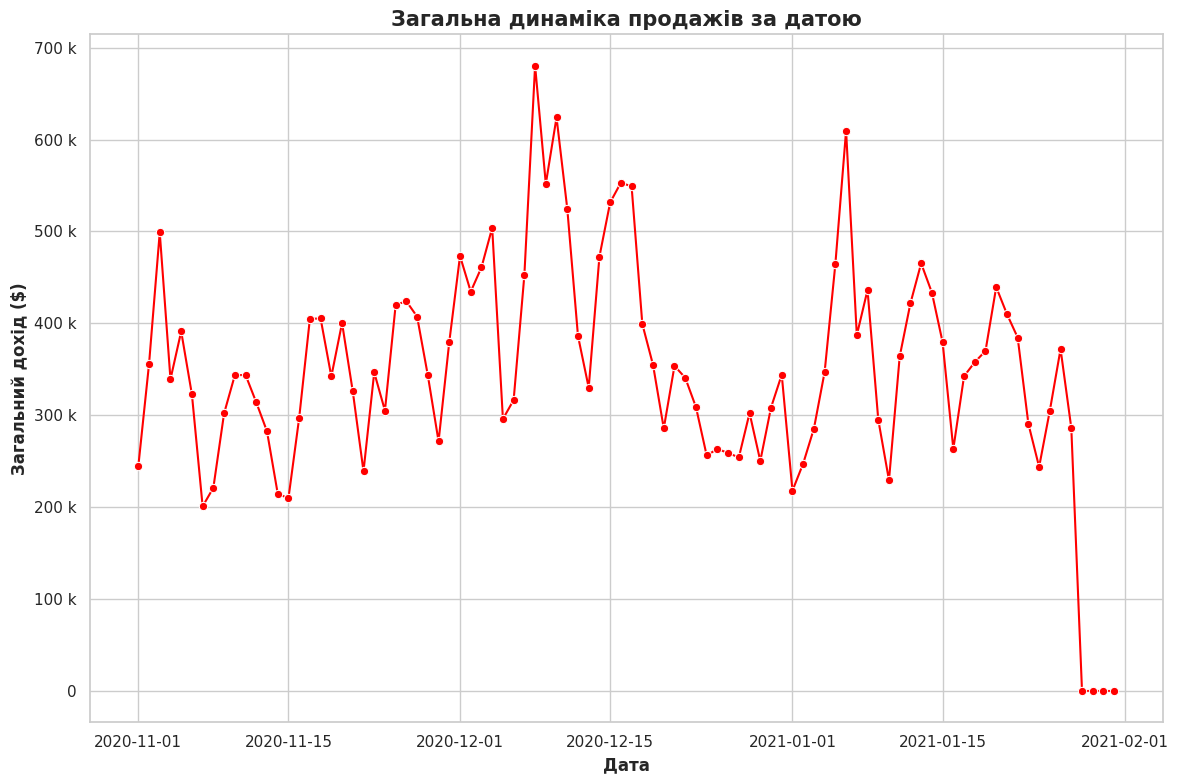

In [66]:
# Розрахунок загальних продажів за кожну дату
total_daily_sales = df.groupby('date')['price'].sum().reset_index()

plt.figure(figsize=(12,8))

# Створення лінійного графіка загальної динаміки продажів
sns.lineplot(
    x='date',
    y='price',
    data=total_daily_sales,
    marker='o',
    color='red'
)

# Задаємо підписи
plt.title(
    'Загальна динаміка продажів за датою'
    , fontsize=15
    , fontweight='bold')

plt.xlabel(
    'Дата'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Загальний дохід ($)'
    , fontsize=12
    , fontweight='bold'
    )
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

По всіх континентах на графіку спостерігається виражена тижнева циклічність та передсвятковий грудневий пік,після якого пішов спад


Але після свят пішло відновлення


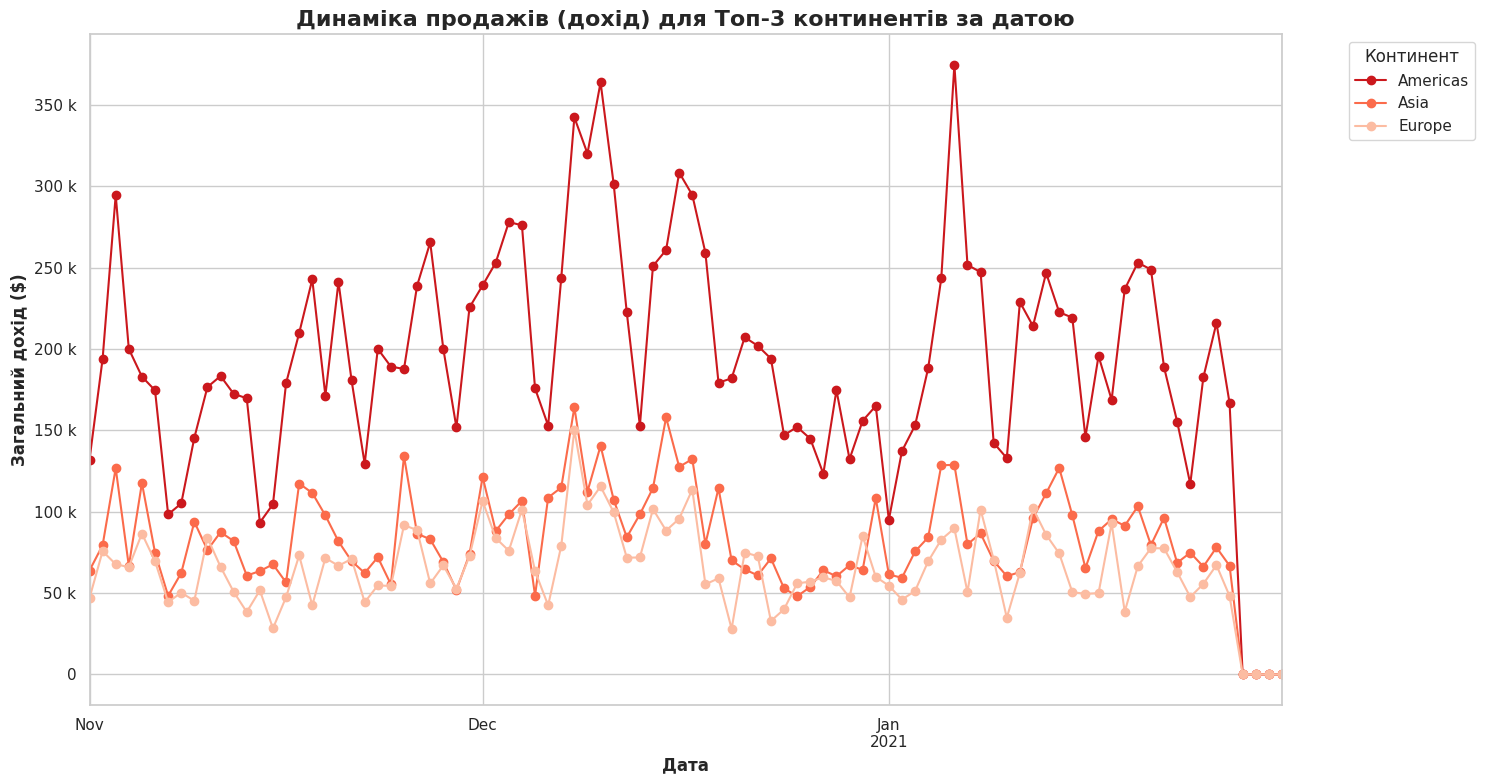

In [67]:
# Знаходимо індекс ТОП 3 континентів
top3_continent_names = df.groupby('continent')['price'].sum().nlargest(3).index
# Робимо фільтрування
df_top_continents = df[df['continent'].isin(top3_continent_names)]
# Групуємо за континентом,датою та сумуємо 'price'
daily_revenue_by_continent = df_top_continents.groupby(['date', 'continent'])['price'].sum().unstack(level='continent')

# Налаштовуємо графік
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Створення лінійного графіка загальної динаміки продажів по континентах
daily_revenue_by_continent.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette('Reds_r', n_colors=len(daily_revenue_by_continent.columns))
)
# Задаємо підписи осей та заголовок
plt.title(
    'Динаміка продажів (дохід) для Топ-3 континентів за датою'
    , fontsize=16
    , fontweight='bold')

plt.xlabel(
    'Дата'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Загальний дохід ($)'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Континент'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left')
plt.grid(True)
# Налаштовуємо формат підписів
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

По всіх континентах на графіку спостерігається виражена тижнева циклічність та передсвятковий грудневий пік,після якого пішов спад


Але після свят пішло відновлення

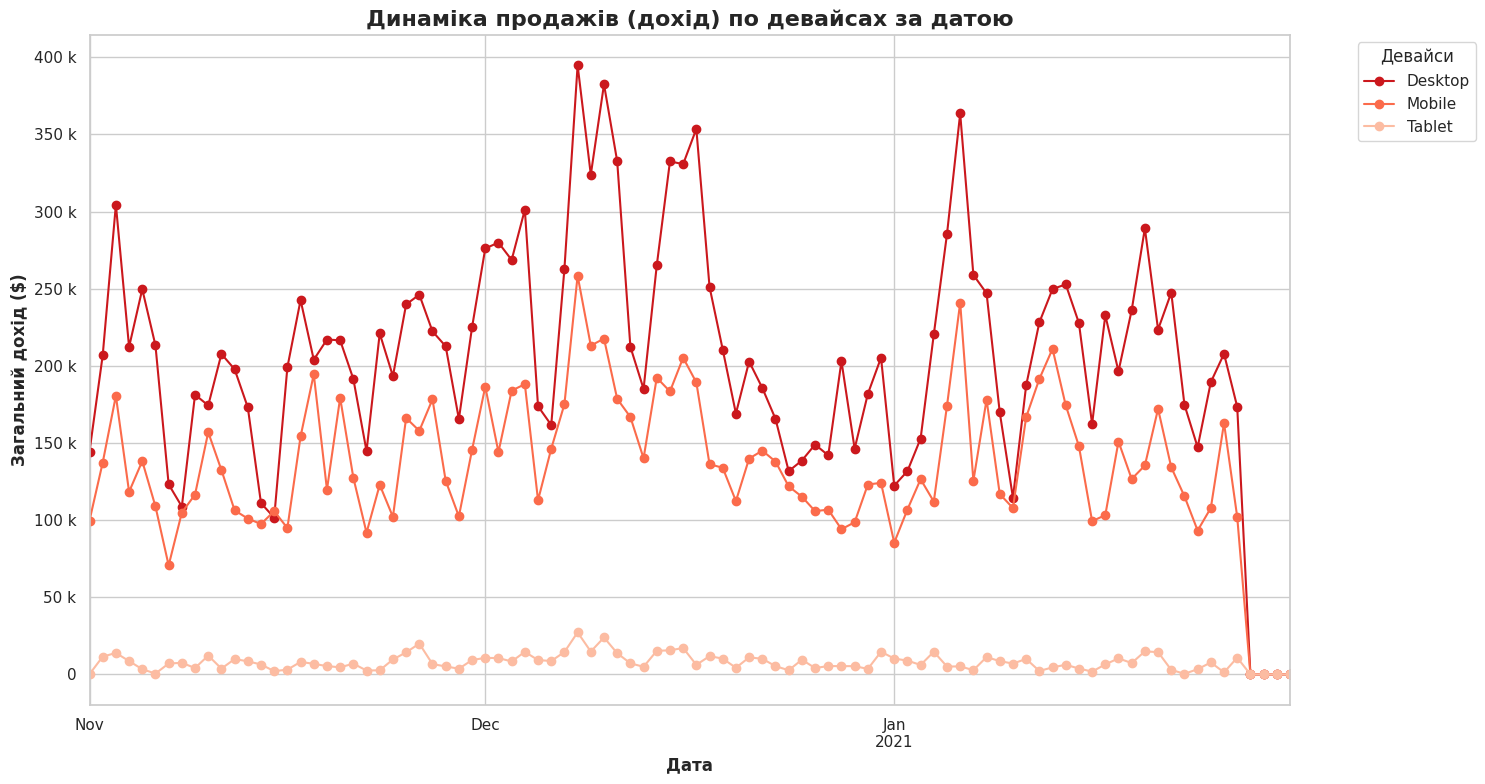

In [68]:
# Групуємо за девайсами,датою та сумуємо 'price'
daily_revenue_by_device= df.groupby(['date', 'device'])['price'].sum().unstack(level='device')

# Налаштовуємо графік
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Створення лінійного графіка загальної динаміки продажів по континентах
daily_revenue_by_device.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette('Reds_r', n_colors=len(daily_revenue_by_device.columns))
)
# Задаємо підписи осей та заголовок
plt.title(
    'Динаміка продажів (дохід) по девайсах за датою'
    , fontsize=16
    , fontweight='bold')

plt.xlabel(
    'Дата'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Загальний дохід ($)'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Девайси'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left')
plt.grid(True)
# Налаштовуємо формат підписів
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

По всіх приистроях на графіку спостерігається виражена тижнева циклічність та передсвятковий грудневий пік,після якого пішов спад

Але після свят пішло відновлення

Також на графіку видно,що найбільші прдажі роблять користуачі що заходять з ноутбуку,а на другому місці ті,хто заходить зі смартфону

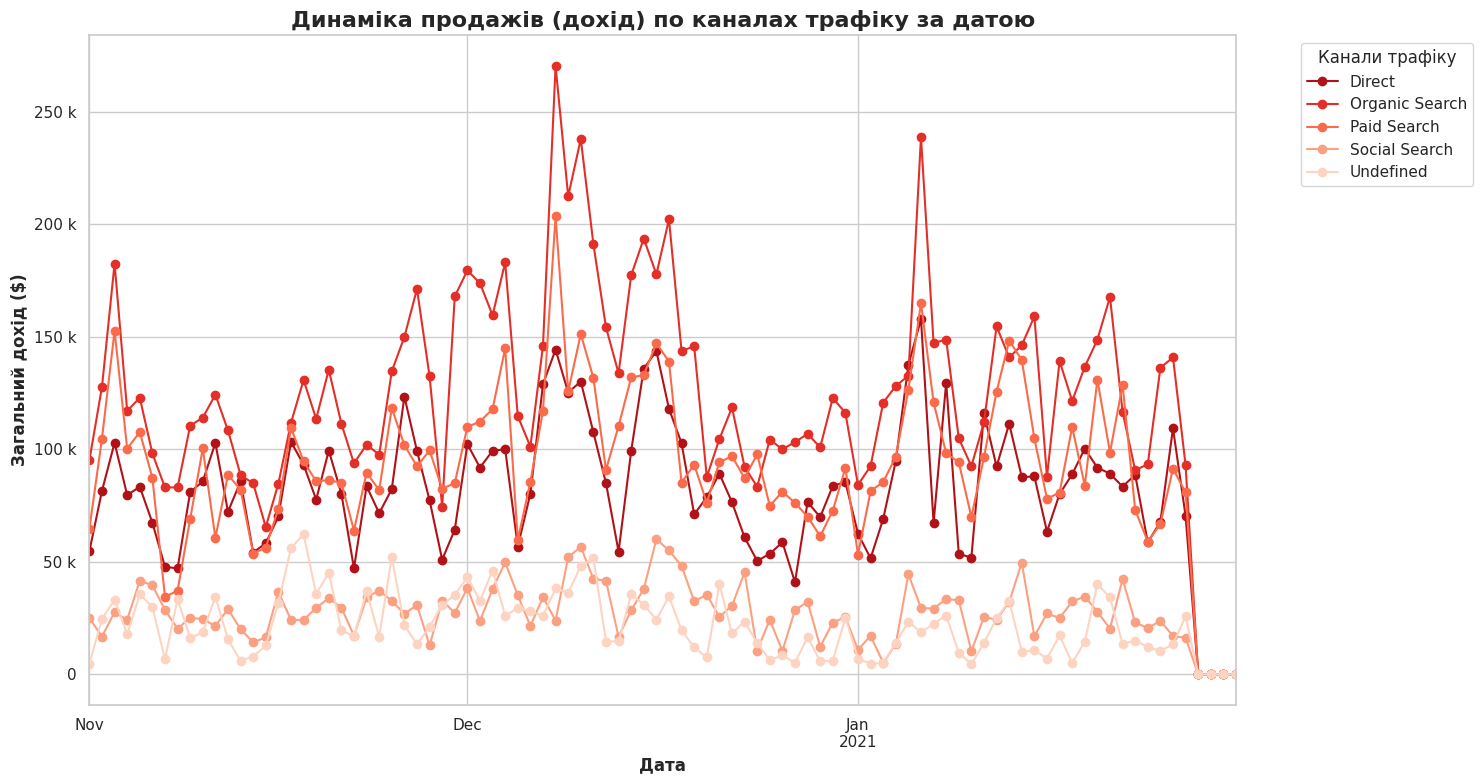

In [69]:
# Групуємо за континентом,датою та сумуємо 'price'
daily_revenue_by_chanel = df.groupby(['date', 'channel'])['price'].sum().unstack(level='channel')

# Налаштовуємо графік
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Створення лінійного графіка загальної динаміки продажів по континентах
daily_revenue_by_chanel.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette('Reds_r', n_colors=len(daily_revenue_by_chanel.columns))
)
# Задаємо підписи осей та заголовок
plt.title(
    'Динаміка продажів (дохід) по каналах трафіку за датою'
    , fontsize=16
    , fontweight='bold')

plt.xlabel(
    'Дата'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Загальний дохід ($)'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Канали трафіку'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left')
plt.grid(True)
# Налаштовуємо формат підписів
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

По каналах трафіку на графіку спостерігається виражена тижнева циклічність та передсвятковий грудневий пік,після якого пішов спад


Але після свят пішло відновлення

Найкращі показники показує Orgenic Search

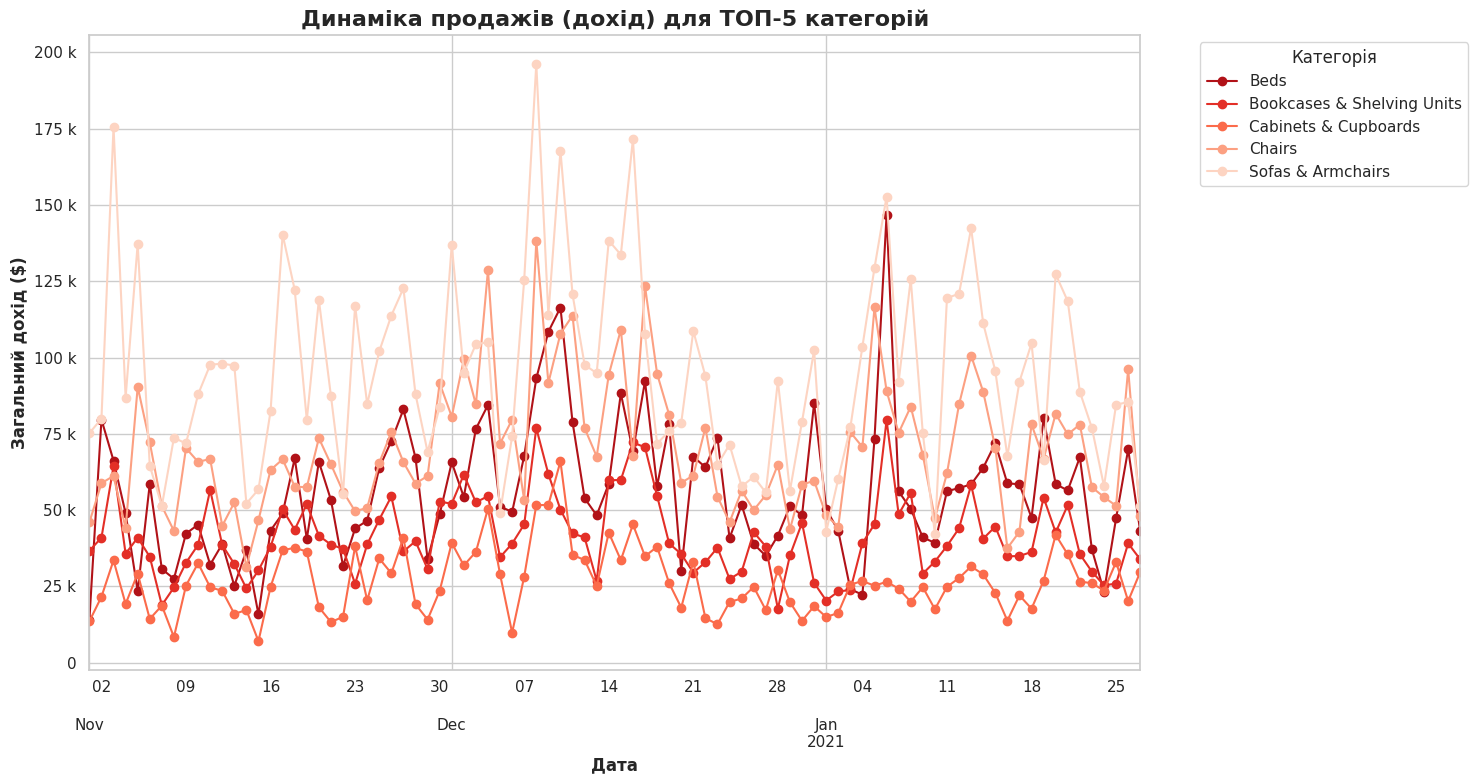

In [70]:
# Знаходимо індекс ТОП 5 категорій
top5_category_names = df.groupby('category')['price'].sum().nlargest(5).index
# Робимо фільтрування
df_top_category = df[df['category'].isin(top5_category_names)]
# Групуємо за категорією,датою та сумуємо 'price'
daily_revenue_by_category = df_top_category.groupby(['date', 'category'])['price'].sum().unstack(level='category')

# Налаштовуємо графік
plt.figure(figsize=(15, 8))
sns.set_theme(style="whitegrid")

# Створення лінійного графіка загальної динаміки продажів по категоріях
daily_revenue_by_category.plot(
    ax=plt.gca(),
    marker='o',
    color=sns.color_palette('Reds_r', n_colors=len(daily_revenue_by_category.columns))
)
# Задаємо підписи осей та заголовок
plt.title(
    'Динаміка продажів (дохід) для ТОП-5 категорій'
    , fontsize=16
    , fontweight='bold')

plt.xlabel(
    'Дата'
    , fontsize=12
    , fontweight='bold'
    )
plt.ylabel(
    'Загальний дохід ($)'
    , fontsize=12
    , fontweight='bold'
    )
plt.legend(
    title='Категорія'
    , bbox_to_anchor=(1.05, 1)
    , loc='upper left')
plt.grid(True)
# Налаштовуємо формат підписів
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())
plt.tight_layout()
plt.show()

По всіх категоріях на графіку спостерігається виражена симметрична тижнева циклічність та передсвятковий грудневий пік,після якого пішов спад


Але після свят пішло відновлення


Найкращі результати показує категорія Sofas&Amchairs

In [71]:
# Створюємо зведену таблицю, яка показує кількість сесій у розрізі каналів трафіку та типів девайсів

session_counts_pivot = df.pivot_table(
    values='session_id',
    index='channel',
    columns='device',
    aggfunc='count'
)
display(session_counts_pivot)

device,Desktop,Mobile,Tablet
channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [72]:
# Створюємо зведену таблицю, яка показує загальні продажі за категоріями товарів (топ-10 категорій) у різних країнах (топ-5 країн)

# Знаходимо топ-10 категорій за загальними продажами
top10_categories = df.groupby('category')['price'].sum().nlargest(10).index.tolist()

# Знаходимо топ-5 країн за загальними продажами
top5_countries = df.groupby('country')['price'].sum().nlargest(5).index.tolist()

# Фільтруємо, щоб включити тільки ці категорії та країни
df_filtered_pivot = df[
    (df['category'].isin(top10_categories)) &
    (df['country'].isin(top5_countries))
]

# 4. Створюємо зведену таблицю
sales_pivot_table = df_filtered_pivot.pivot_table(
    values='price',
    index='category',
    columns='country',
    aggfunc='sum',
    fill_value=0  # Заповнюємо відсутні значення нулями
)

display(sales_pivot_table)

country,Canada,France,India,United Kingdom,United States
category,,,,,
Bar Furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & Shelving Units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & Cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests Of Drawers & Drawer Units,71952.0,21544.5,73111.0,36784.0,382388.0
Children'S Furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor Furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & Armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [73]:
# Створюємо зведену таблицю, яка показує середній прайс у розрізі країн та типів девайсів

session_counts_pivot = df_filtered_pivot.pivot_table(
    values='price',
    index='channel',
    columns='country',
    aggfunc='sum'
)
display(session_counts_pivot)

country,Canada,France,India,United Kingdom,United States
channel,,,,,
Direct,601511.3,167178.5,692615.0,199058.9,3303099.3
Organic Search,862732.7,257924.6,956387.7,353100.9,4886229.0
Paid Search,655353.0,188990.3,717190.0,270733.6,3528245.4
Social Search,150019.2,46248.4,215313.8,51321.0,1113863.1
Undefined,128048.8,40555.0,184339.5,47216.5,898570.1


In [74]:
# Створюємо зведену таблицю, яка показує середній прайс у розрізі країн та типів девайсів

session_counts_pivot = df_filtered_pivot.pivot_table(
    values='price',
    index='device',
    columns='country',
    aggfunc='sum'
)
display(session_counts_pivot)

country,Canada,France,India,United Kingdom,United States
device,,,,,
Desktop,1409078.1,410760.5,1612753.7,535274.9,8148905.1
Mobile,939424.5,276241.3,1073607.9,365253.0,5270061.9
Tablet,49162.4,13895.0,79484.4,20903.0,311039.9


        date  total_sessions  total_sales
0 2020-11-01            2576      21547.0
1 2020-11-02            3599      44956.8
2 2020-11-03            5173      29150.5
3 2020-11-04            4184      20982.2
4 2020-11-05            3743      25334.6


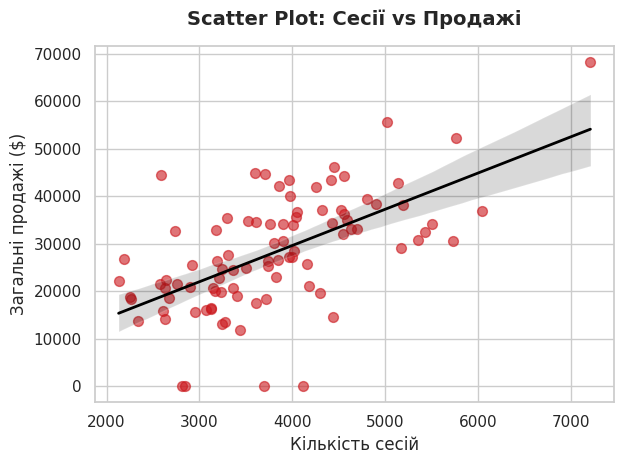

In [75]:

# Розраховуємо загальну кількість унікальних сесій за день з повного датафрейму 'df'
total_daily_sessions = df.groupby('date')['session_id'].nunique().reset_index()
total_daily_sessions.rename(columns={'session_id': 'total_sessions'}, inplace=True)

# Розраховуємо загальну суму продажів за день з 'sales_df'
total_daily_sales = sales_df.groupby('date')['price'].sum().reset_index()
total_daily_sales.rename(columns={'price': 'total_sales'}, inplace=True)

# Об'єднуємо обидва датафрейми за датою
daily_metrics = pd.merge(total_daily_sessions, total_daily_sales, on='date', how='left')
# Заповнюємо NaN лише в колонці 'total_sales' нулями, де не було продажів
daily_metrics['total_sales'] = daily_metrics['total_sales'].fillna(0)

print(daily_metrics.head())

sns.set_theme(style="whitegrid")

# Будуємо Scatter Plot з лінією регресії
sns.regplot(
    data=daily_metrics,
    x='total_sessions',
    y='total_sales',
    color='#cb181d',
    scatter_kws={'alpha': 0.6, 's': 50},
    line_kws={'color': 'black', 'linewidth': 2}
)
plt.title('Scatter Plot: Сесії vs Продажі', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Кількість сесій', fontsize=12)
plt.ylabel('Загальні продажі ($)', fontsize=12)


plt.tight_layout()
plt.show()

In [76]:
from scipy import stats
# Розрахунок кореляції Пірсона та p-value
corr_coef, p_value = stats.pearsonr(daily_metrics['total_sessions'], daily_metrics['total_sales'])

print(f"📊 РЕЗУЛЬТАТИ КОРЕЛЯЦІЙНОГО АНАЛІЗУ:")
print(f"------------------------------------")
print(f"Коефіцієнт кореляції Пірсона (r): {corr_coef:.4f}")
print(f"p-value: {p_value:.4e}")

# Перевірка статистичної значущості (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print(f"\nВисновок: Кореляція є СТАТИСТИЧНО ЗНАЧУЩОЮ (p-value < {alpha}).")
else:
    print(f"\nВисновок: Кореляція НЕ є статистично значущою (p-value >= {alpha}).")

📊 РЕЗУЛЬТАТИ КОРЕЛЯЦІЙНОГО АНАЛІЗУ:
------------------------------------
Коефіцієнт кореляції Пірсона (r): 0.6031
p-value: 1.9965e-10

Висновок: Кореляція є СТАТИСТИЧНО ЗНАЧУЩОЮ (p-value < 0.05).


На scatter plot видно сильний позитивний звʼязок між кількітю сессій та загальними продажами,та цей звʼязок є СТАТИСТИЧНО ЗНАЧУЩИМ за Пірсоном

Топ-3 континенти за виручкою: ['Americas', 'Asia', 'Europe']

📊 МАТРИЦЯ КОРЕЛЯЦІЇ:
continent  Americas   Asia  Europe
continent                         
Americas      1.000  0.692   0.670
Asia          0.692  1.000   0.668
Europe        0.670  0.668   1.000

🔍 МАТРИЦЯ P-VALUE:
continent    Americas        Asia      Europe
continent                                    
Americas   1.0000e+00  8.0041e-14  9.9114e-13
Asia       8.0041e-14  1.0000e+00  1.1909e-12
Europe     9.9114e-13  1.1909e-12  1.0000e+00


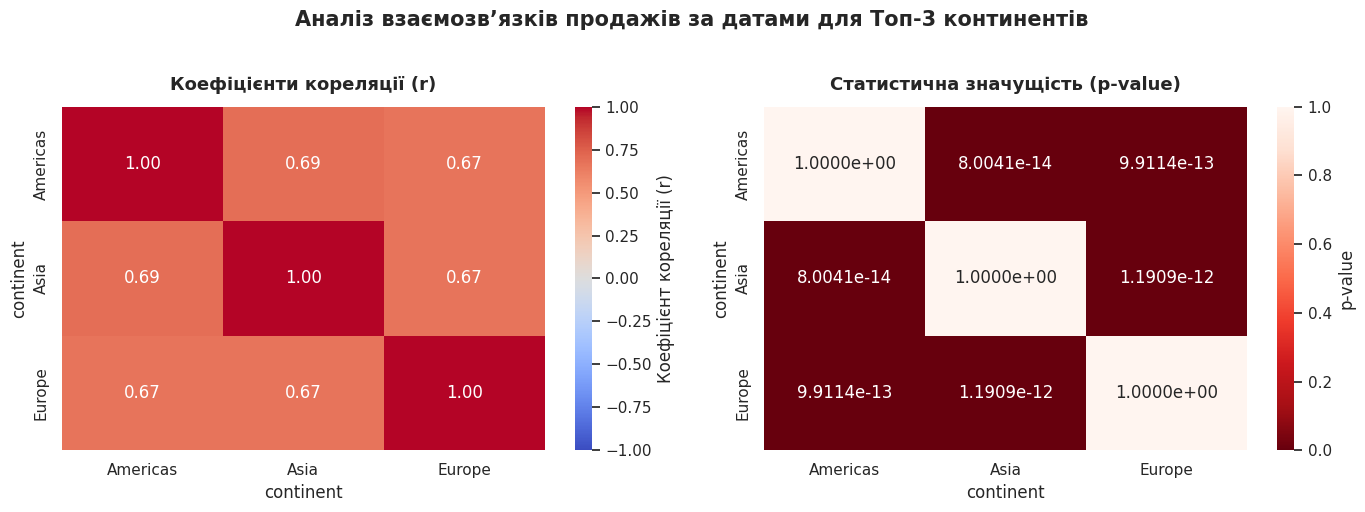

In [93]:
top3_continents = (
    sales_df.groupby('continent')['price']
    .sum()
    .nlargest(3)
    .index.tolist()
)

print(f"Топ-3 континенти за виручкою: {top3_continents}\n")

# Створення зведеної таблиці продажів за датами для Топ-3 континентів
pivot_sales = sales_df[sales_df['continent'].isin(top3_continents)].pivot_table(
    index='date',
    columns='continent',
    values='price',
    aggfunc='sum'
).fillna(0)

# Обчислення матриці кореляцій та p-value для кожної пари
corr_matrix = pivot_sales.corr()
pval_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2:
            r, p = stats.pearsonr(pivot_sales[col1], pivot_sales[col2])
            pval_matrix.loc[col1, col2] = p

print("📊 МАТРИЦЯ КОРЕЛЯЦІЇ:")
print(corr_matrix.round(3))
print("\n🔍 МАТРИЦЯ P-VALUE:")
print(pval_matrix.map(lambda x: f"{x:.4e}"))

# Створюємо маску значущості (True там, де p-value < 0.05)
significant_mask = pval_matrix < 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")

# Матриця коефіцієнтів кореляції
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)
axes[0].set_title('Коефіцієнти кореляції (r)', fontsize=13, fontweight='bold', pad=12)

# Матриця статистичної значущості (P-value)
sns.heatmap(
    pval_matrix,
    annot=True,
    fmt=".4e", # для експоненціального формату
    cmap="Reds_r",
    vmax=1, # для повного діапазону кольорової шкали
    ax=axes[1],
    cbar_kws={'label': 'p-value'}
)
axes[1].set_title('Статистична значущість (p-value)', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Аналіз взаємозв’язків продажів за датами для Топ-3 континентів', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


*   **Americas vs Asia ($r = 0.692$):**
    *   **P-value:** значно менше $0.05$


*   **Americas vs Europe ($r = 0.670$):**
    *   **P-value: значно менше $0.05$

*   **Asia vs Europe ($r = 0.668$):**
    *   **P-value:** $1.1909e-12$ (що значно менше $0.05$).
  
---
Аналіз показує, що між щоденними обсягами продажів усіх пар провідних трьох континентів (Америка, Азія, Європа) існують **сильні позитивні та статистично значущі взаємозв'язки**. Це свідчить про те, що продажі на цих континентах реагують на подібні фактори або глобальні ринкові тенденції, рухаючись у синхронному напрямку. Також це може вказувати на взаємозалежність або спільні причини в їхній динаміці продажів.

Оцінка рівня кореляції

* **Americas vs Asia ($r=$0.239$):**
Спостерігається позитивний зв'язок,що є статистично значущим.

* **Americas vs Europe ($r = $0.088$):** Зв'язок фактично відсутній.

* **Asia vs Europe ($r = $0.092$):** Зв'язок фактично відсутній.

---

Оцінка статистичної значущості

* **Americas vs Asia :** Значення $p < 0.05$.

**Висновок:** Кореляція ($r = 0.24$) є **статистично значущою**. Зв'язок між ринками Америки та Азії дійсно існує і не є випадковим шумом.


* **Americas vs Europe :** Значення $p > 0.05$.

**Висновок:** Результат **статистично незначущий**.


* **Asia vs Europe :** Значення $p > 0.05$.

**Висновок:** Результат **статистично незначущий**.


📊 МАТРИЦЯ КОРЕЛЯЦІЇ (r):
channel         Direct  Organic Search  Paid Search  Social Search  Undefined
channel                                                                      
Direct           1.000           0.760        0.724          0.462      0.424
Organic Search   0.760           1.000        0.808          0.434      0.435
Paid Search      0.724           0.808        1.000          0.452      0.430
Social Search    0.462           0.434        0.452          1.000      0.359
Undefined        0.424           0.435        0.430          0.359      1.000

🔍 МАТРИЦЯ P-VALUE:
channel             Direct Organic Search Paid Search Social Search  \
channel                                                               
Direct          1.0000e+00     9.1079e-18  1.5129e-15    5.9010e-06   
Organic Search  9.1079e-18     1.0000e+00  1.7556e-21    2.3476e-05   
Paid Search     1.5129e-15     1.7556e-21  1.0000e+00    9.6960e-06   
Social Search   5.9010e-06     2.3476e-05  9.6960e-06 

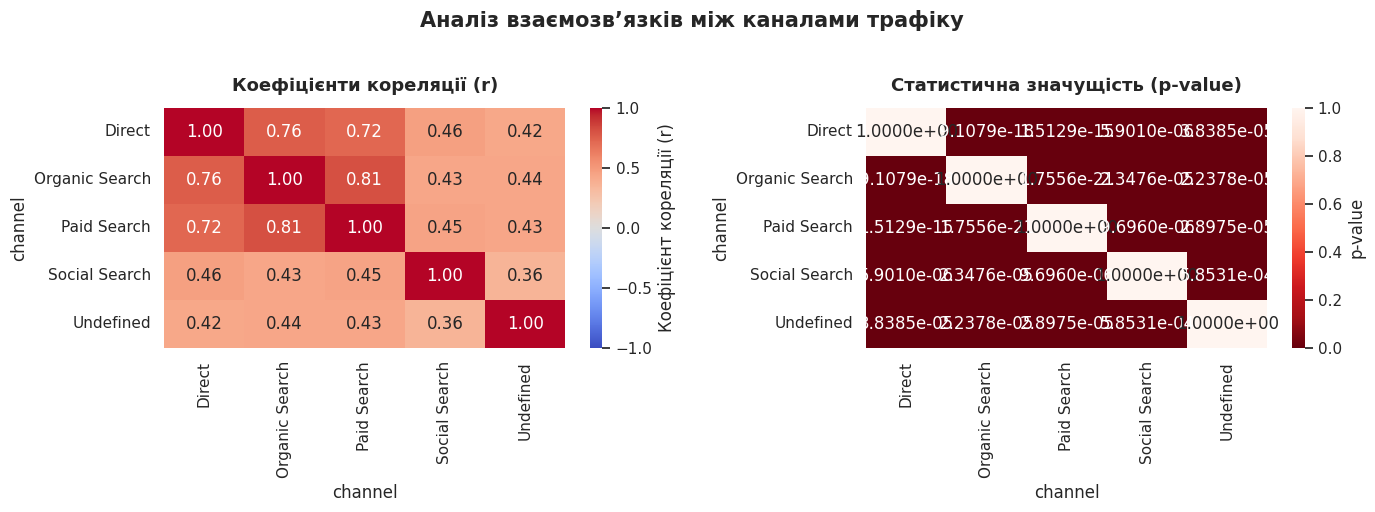

In [88]:
pivot_channels = sales_df.pivot_table(
    index='date',
    columns='channel',
    values='price',
    aggfunc='sum'
).fillna(0)


# Обчислення коефіцієнтів кореляції Пірсона та p-value
corr_matrix = pivot_channels.corr()
pval_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2:
            r, p = stats.pearsonr(pivot_channels[col1], pivot_channels[col2])
            pval_matrix.loc[col1, col2] = p
            pval_matrix.loc[col2, col1] = p # Забезпечуємо симетрію

print("📊 МАТРИЦЯ КОРЕЛЯЦІЇ (r):")
print(corr_matrix.round(3))
print("\n🔍 МАТРИЦЯ P-VALUE:")
print(pval_matrix.map(lambda x: f"{x:.4e}"))


# Створюємо маску значущості (True там, де p-value < 0.05)
significant_mask = pval_matrix < 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")

# Матриця коефіцієнтів кореляції
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)
axes[0].set_title('Коефіцієнти кореляції (r)', fontsize=13, fontweight='bold', pad=12)

# Матриця статистичної значущості (P-value)
sns.heatmap(
    pval_matrix,
    annot=True,
    fmt=".4e", #  експоненціальний формат для кращої читабельності p-значень
    cmap="Reds_r",
    vmax=1, #для повного діапазону кольорової шкали
    ax=axes[1],
    cbar_kws={'label': 'p-value'}
)
axes[1].set_title('Статистична значущість (p-value)', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Аналіз взаємозв’язків між каналами трафіку', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

*   **Дуже сильні позитивні кореляції (r > 0.75):**
    *   **Organic Search** та **Paid Search** (r = 0.808): Найсильніший зв'язок, що вказує на тісну взаємодію цих каналів. Зростання або падіння продажів в одному каналі тісно пов'язане зі зростанням/падінням в іншому.
    *   **Direct** та **Organic Search** (r = 0.760): Також сильний зв'язок, що підкреслює їхню скоординовану динаміку.

*   **Сильні позитивні кореляції (0.7 < r ≤ 0.75):**
    *   **Direct** та **Paid Search** (r = 0.724): Продажі через ці канали також значно корелюють.

*   **Помірні позитивні кореляції (0.3 < r ≤ 0.7):**
    *   **Direct** та **Social Search** (r = 0.462)
    *   **Direct** та **Undefined** (r = 0.424)
    *   **Organic Search** та **Social Search** (r = 0.434)
    *   **Organic Search** та **Undefined** (r = 0.435)
    *   **Paid Search** та **Social Search** (r = 0.452)
    *   **Paid Search** та **Undefined** (r = 0.430)
    *   **Social Search** та **Undefined** (r = 0.359)


Топ-5 категорій за виручкою: ['Sofas & Armchairs', 'Chairs', 'Beds', 'Bookcases & Shelving Units', 'Cabinets & Cupboards']

📊 МАТРИЦЯ КОРЕЛЯЦІЇ:
category                     Beds  Bookcases & Shelving Units  \
category                                                        
Beds                        1.000                       0.593   
Bookcases & Shelving Units  0.593                       1.000   
Cabinets & Cupboards        0.515                       0.539   
Chairs                      0.554                       0.637   
Sofas & Armchairs           0.535                       0.666   

category                    Cabinets & Cupboards  Chairs  Sofas & Armchairs  
category                                                                     
Beds                                       0.515   0.554              0.535  
Bookcases & Shelving Units                 0.539   0.637              0.666  
Cabinets & Cupboards                       1.000   0.573              0.658  
Chairs   

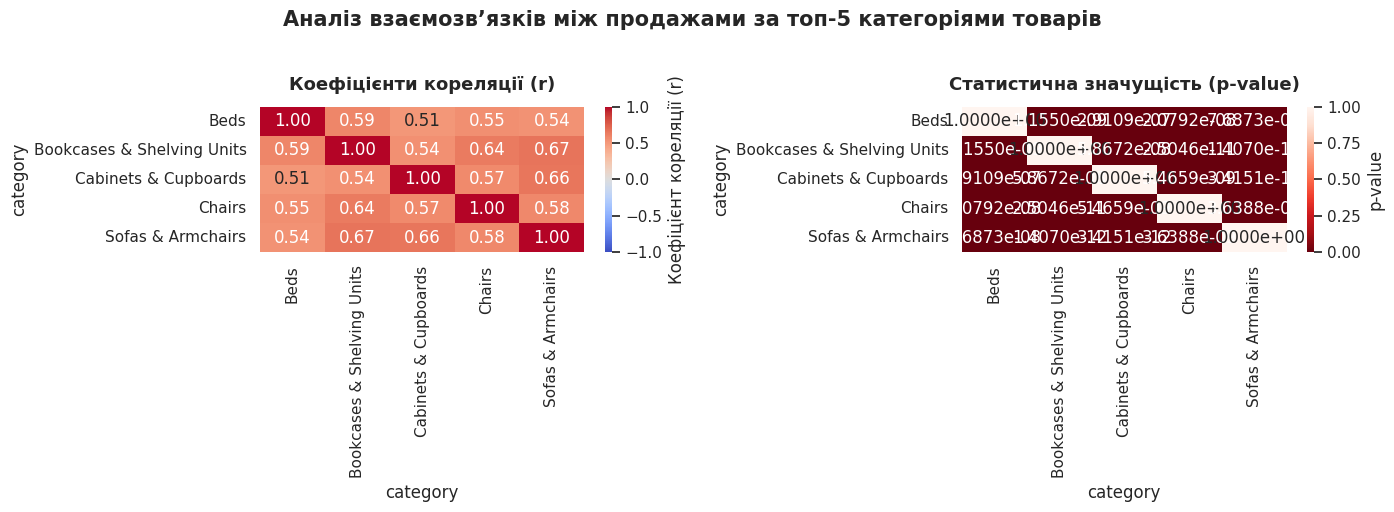

In [96]:
top5_сategory = (
    sales_df.groupby('category')['price']
    .sum()
    .nlargest(5)
    .index.tolist()
)

print(f"Топ-5 категорій за виручкою: {top5_сategory}\n")

# Створення зведеної таблиці продажів за датами для Топ-3 континентів
pivot_sales = sales_df[sales_df['category'].isin(top5_сategory)].pivot_table(
    index='date',
    columns='category',
    values='price',
    aggfunc='sum'
).fillna(0)

# Обчислення матриці кореляцій та p-value для кожної пари
corr_matrix = pivot_sales.corr()
pval_matrix = pd.DataFrame(np.ones_like(corr_matrix), index=corr_matrix.index, columns=corr_matrix.columns)

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 != col2:
            r, p = stats.pearsonr(pivot_sales[col1], pivot_sales[col2])
            pval_matrix.loc[col1, col2] = p

print("📊 МАТРИЦЯ КОРЕЛЯЦІЇ:")
print(corr_matrix.round(3))
print("\n🔍 МАТРИЦЯ P-VALUE:")
print(pval_matrix.map(lambda x: f"{x:.4e}"))


# Створюємо маску значущості (True там, де p-value < 0.05)
significant_mask = pval_matrix < 0.05

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")

# Матриця коефіцієнтів кореляції
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)
axes[0].set_title('Коефіцієнти кореляції (r)', fontsize=13, fontweight='bold', pad=12)

# Матриця статистичної значущості (P-value)
sns.heatmap(
    pval_matrix,
    annot=True,
    fmt=".4e", # для експоненціального формату
    cmap="Reds_r",
    vmax=1, # для повного діапазону кольорової шкали
    ax=axes[1],
    cbar_kws={'label': 'p-value'}
)
axes[1].set_title('Статистична значущість (p-value)', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Аналіз взаємозв’язків між продажами за топ-5 категоріями товарів', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Аналіз кореляції між щоденними продажами п'яти найбільш прибуткових категорій товарів показує, що **всі виявлені взаємозв'язки є позитивними, від помірних до сильних, і статистично значущими** (усі p-значення значно менші за 0.05).

Це означає, що динаміка щоденних продажів у цих категоріях, як правило, рухається в одному напрямку. Зростання або падіння продажів в одній категорії часто супроводжується подібними змінами в інших категоріях, що свідчить про їхню взаємозалежність, а не незалежність.



📊 МАТРИЦЯ КОРЕЛЯЦІЇ (AOV за категоріями):
category                     Beds  Bookcases & Shelving Units  \
category                                                        
Beds                        1.000                       0.040   
Bookcases & Shelving Units  0.040                       1.000   
Cabinets & Cupboards       -0.026                      -0.189   
Chairs                      0.125                       0.004   
Sofas & Armchairs          -0.072                       0.118   

category                    Cabinets & Cupboards  Chairs  Sofas & Armchairs  
category                                                                     
Beds                                      -0.026   0.125             -0.072  
Bookcases & Shelving Units                -0.189   0.004              0.118  
Cabinets & Cupboards                       1.000   0.036              0.080  
Chairs                                     0.036   1.000             -0.039  
Sofas & Armchairs                 

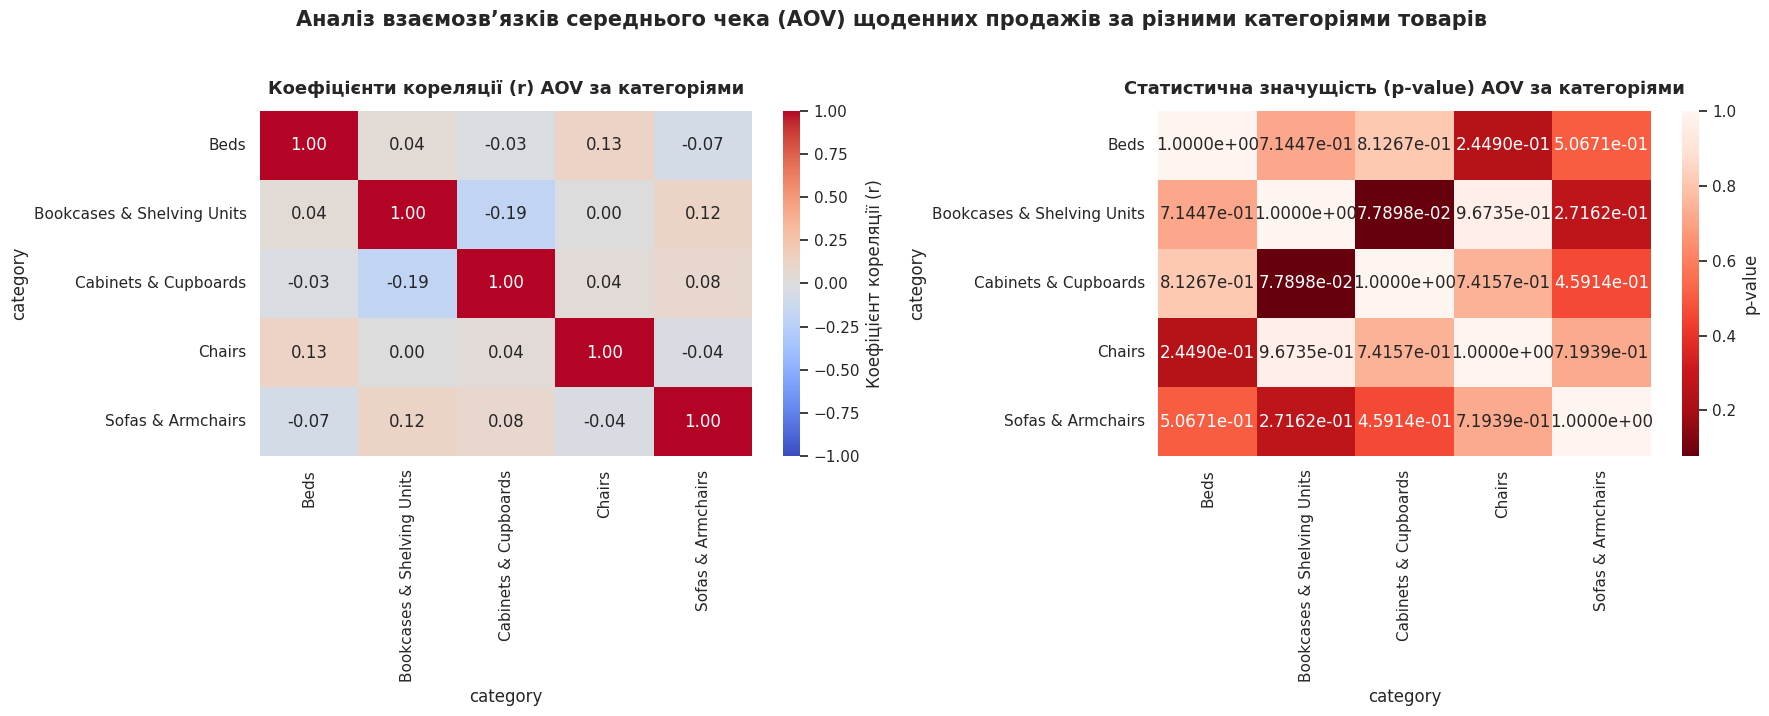

In [97]:
# Знаходимо ТОП-5 категорій за загальною сумою продажі
top10_categories_for_aov = sales_df.groupby('category')['price'].sum().nlargest(5).index.tolist()

# Фільтруємо sales_df, щоб залишити лише дані для ТОП-5 категорій
sales_df_filtered = sales_df[sales_df['category'].isin(top10_categories_for_aov)]

# Створення зведеної таблиці середнього чека (AOV) за датами для різних категорій
pivot_aov_by_category = sales_df_filtered.groupby(['date', 'category'])['price'].mean().unstack(level='category').fillna(0)

# Обчислення матриці кореляцій та p-value для кожної пари
corr_matrix_aov = pivot_aov_by_category.corr()
pval_matrix_aov = pd.DataFrame(np.ones_like(corr_matrix_aov), index=corr_matrix_aov.index, columns=corr_matrix_aov.columns)

for col1 in corr_matrix_aov.columns:
    for col2 in corr_matrix_aov.columns:
        if col1 != col2:
            r, p = stats.pearsonr(pivot_aov_by_category[col1], pivot_aov_by_category[col2])
            pval_matrix_aov.loc[col1, col2] = p

print("📊 МАТРИЦЯ КОРЕЛЯЦІЇ (AOV за категоріями):")
print(corr_matrix_aov.round(3))
print("\n🔍 МАТРИЦЯ P-VALUE (AOV за категоріями):")
print(pval_matrix_aov.map(lambda x: f"{x:.4e}"))


# Створюємо маску значущості (True там, де p-value < 0.05)
significant_mask_aov = pval_matrix_aov < 0.05

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="white")

# Матриця коефіцієнтів кореляції
sns.heatmap(
    corr_matrix_aov,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=axes[0],
    cbar_kws={'label': 'Коефіцієнт кореляції (r)'}
)
axes[0].set_title('Коефіцієнти кореляції (r) AOV за категоріями', fontsize=13, fontweight='bold', pad=12)

# Матриця статистичної значущості (P-value)
sns.heatmap(
    pval_matrix_aov,
    annot=True,
    fmt=".4e", # Оновлено для експоненціального формату
    cmap="Reds_r",
    vmax=1, # Оновлено vmax на 1 для повного діапазону кольорової шкали
    ax=axes[1],
    cbar_kws={'label': 'p-value'}
)
axes[1].set_title('Статистична значущість (p-value) AOV за категоріями', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Аналіз взаємозв’язків середнього чека (AOV) щоденних продажів за різними категоріями товарів', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Коефіцієнти кореляції Пірсона (r) між середнім чеком різних категорій товарів близькі до нуля (в діапазоні від −0.19 до +0.13), а значення p-value у всіх випадках значно перевищують рівень значущості 0.05 (p>0.05).

Динаміка середнього чека (AOV) у різних товарних категоріях є незалежною. Зміна вартості покупки в одній категорії (наприклад, Sofas & Armchairs) не впливає на середній чек в інших (Beds, Chairs тощо). Це означає, що для кожної товарної категорії потрібні окремі цінові та маркетингові стратегії, а крос-селл-активності слід налаштовувати персоналізовано під конкретні товари.

📊 ОПИСОВА СТАТИСТИКА ВИБІРОК (Денні продажі):
       registered      guest
count       88.00      88.00
mean     29346.80  333968.32
std      10765.45   92910.21
min      11779.00  182206.20
25%      20717.38  270485.50
50%      28048.00  316724.25
75%      35774.70  379948.48
max      68151.10  612358.40
------------------------------------------------------------
🔍 Перевірка на нормальність (Shapiro-Wilk Test):
• Зареєстровані користувачі: p-value = 7.2951e-03
• Незареєстровані гості:     p-value = 2.6183e-03
------------------------------------------------------------


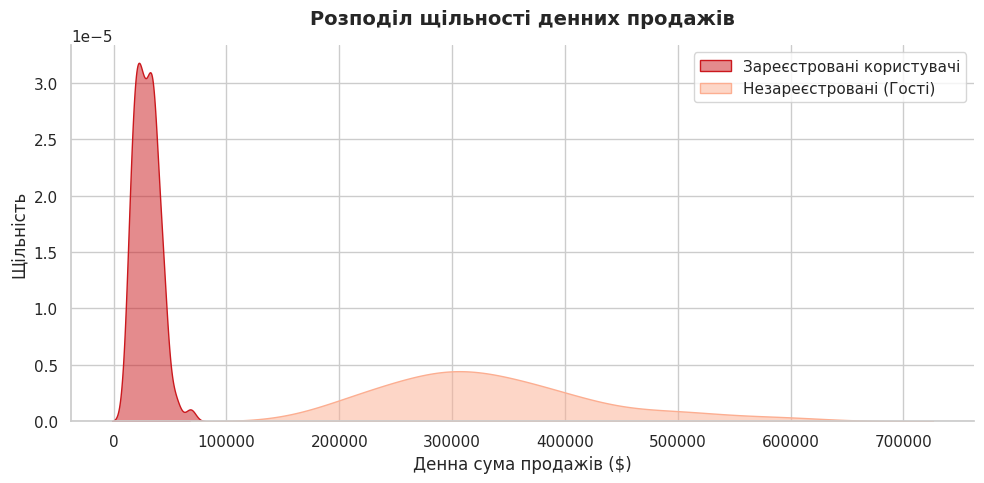

⚡ РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ ВІЛКОКСОНА:
• T-статистика: 0.0
• p-value:     3.7320e-16

✅ Висновок: Різниця у денних продажах між зареєстрованими та незареєстрованими користувачами є СТАТИСТИЧНО ЗНАЧУЩОЮ (p-value < 0.05).


In [98]:
# Забезпечуємо, що sales_df містить УСІ продажі (з ціною > 0) перед поділом
sales_df = df[df['price'] > 0].copy()

# Розділяємо на дві групи: зареєстровані акаунти та незареєстровані гості
registered_sales = sales_df[sales_df['account_id'].notna()]
guest_sales = sales_df[sales_df['account_id'].isna()]

# Агрегуємо сумарні продажі за кожну дату
reg_daily = registered_sales.groupby('date')['price'].sum()
guest_daily = guest_sales.groupby('date')['price'].sum()

# Об'єднуємо обидві вибірки в один DataFrame за датами
daily_sales_df = pd.DataFrame({
    'registered': reg_daily,
    'guest': guest_daily
}).fillna(0)

print("📊 ОПИСОВА СТАТИСТИКА ВИБІРОК (Денні продажі):")
print(daily_sales_df.describe().round(2))
print("-" * 60)

# --- КРОК 2: Аналіз розподілів даних ---

# 1. Тест Шапіро-Уїлка (Shapiro-Wilk) на нормальність розподілу
stat_reg, p_reg = stats.shapiro(daily_sales_df['registered'])
# Додаємо умову, щоб уникнути попередження, якщо діапазон значень дорівнює нулю
if daily_sales_df['guest'].min() == daily_sales_df['guest'].max():
    print("  • Незареєстровані гості: Діапазон значень для тесту Шапіро-Уїлка дорівнює нулю. Припускаємо ненормальний розподіл або відсутність варіації.")
    p_guest = 0.0 # Встановлюємо p-value як 0.0, щоб показати відсутність нормального розподілу або варіації
else:
    stat_guest, p_guest = stats.shapiro(daily_sales_df['guest'])

print(f"🔍 Перевірка на нормальність (Shapiro-Wilk Test):")
print(f"• Зареєстровані користувачі: p-value = {p_reg:.4e}")
print(f"• Незареєстровані гості:     p-value = {p_guest:.4e}")
print("-" * 60)

# 2. Візуалізація розподілів (KDE Plot)
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.kdeplot(daily_sales_df['registered'], fill=True, label='Зареєстровані користувачі', color='#cb181d', alpha=0.5)

# Додаємо умову для KDE plot, щоб уникнути попередження про нульову дисперсію
if daily_sales_df['guest'].var() > 0:
    sns.kdeplot(daily_sales_df['guest'], fill=True, label='Незареєстровані (Гості)', color='#fcae91', alpha=0.5)
else:
    print("• Незареєстровані гості: Розподіл щільності не відображено через нульову дисперсію (всі значення однакові).")

plt.title('Розподіл щільності денних продажів', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Денна сума продажів ($)', fontsize=12)
plt.ylabel('Щільність', fontsize=12)
plt.legend(fontsize=11)

sns.despine()
plt.tight_layout()
plt.show()

# --- КРОК 3: Підбір та проведення статистичного тесту ---

# Оскільки порівнюються продажі в одні й ті самі дні (парні/залежні спостереження)
# та розподіли не є нормально розподіленими (p-value < 0.05 в Shapiro-Wilk),
# найкраще підходить парний непараметричний тест Вілкоксона (Wilcoxon Signed-Rank Test).

# Додаємо перевірку на наявність варіації, щоб уникнути помилок у Wilcoxon тесті, якщо одна з вибірок має нульовий діапазон.
if daily_sales_df['registered'].min() == daily_sales_df['registered'].max() and \
   daily_sales_df['guest'].min() == daily_sales_df['guest'].max():
    print("Обидві вибірки мають нульовий діапазон, Wilcoxon Signed-Rank Test не може бути застосований.")
elif daily_sales_df['registered'].min() == daily_sales_df['registered'].max():
    # Якщо лише 'registered' має нульовий діапазон, а 'guest' ні, то очевидно, що є різниця
    stat_wilc = 0.0 # Символічне значення
    p_val_wilc = 0.0 # Символічне значення
    print("Зареєстровані продажі мають нульовий діапазон, але гостьові продажі варіюються. Різниця є значущою.")
elif daily_sales_df['guest'].min() == daily_sales_df['guest'].max():
    # Якщо лише 'guest' має нульовий діапазон, а 'registered' ні, то очевидно, що є різниця
    stat_wilc = 0.0 # Символічне значення
    p_val_wilc = 0.0 # Символічне значення
    print("Гостьові продажі мають нульовий діапазон, але зареєстровані продажі варіюються. Різниця є значущою.")
else:
    stat_wilc, p_val_wilc = stats.wilcoxon(daily_sales_df['registered'], daily_sales_df['guest'])

print("⚡ РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ ВІЛКОКСОНА:")
print(f"• T-статистика: {stat_wilc}")
print(f"• p-value:     {p_val_wilc:.4e}")

alpha = 0.05
if p_val_wilc < alpha:
    print(f"\n✅ Висновок: Різниця у денних продажах між зареєстрованими та незареєстрованими користувачами є СТАТИСТИЧНО ЗНАЧУЩОЮ (p-value < {alpha}).")
else:
    print(f"\n❌ Висновок: Статистично значущої різниці між денними продажами обох груп НЕ виявлено (p-value >= {alpha}).")

Абсолютну більшість щоденного валового доходу компанії генерують незареєстровані гості.

Зареєстровані акаунти формують стабільний, але в рази менший щоденний прибуток.

 З точки зору бізнес-процесів необхідно або спрощувати процес реєстрації, або дослідити, чому лояльні/зареєстровані клієнти купують на значно менші суми, ніж разові відвідувачі.

📊 Описова статистика щоденної кількості сесій за каналами:
channel   Direct  Organic Search  Paid Search  Social Search  Undefined
count      92.00           92.00        92.00          92.00      92.00
mean      884.59         1352.45      1025.45         303.41     233.51
std       220.23          336.57       254.42          88.13      83.63
min       481.00          733.00       578.00         137.00      86.00
25%       744.00         1117.25       860.25         235.50     160.75
50%       869.50         1329.00       989.00         308.00     229.00
75%      1004.75         1558.75      1171.75         358.25     293.25
max      1668.00         2589.00      1959.00         561.00     435.00


🔍 Перевірка на нормальність розподілу (Shapiro-Wilk Test) для щоденних сесій по каналах:
  Канал 'Direct': p-value = 3.4279e-02 (не нормальний)
  Канал 'Organic Search': p-value = 1.2272e-02 (не нормальний)
  Канал 'Paid Search': p-value = 1.0833e-02 (не нормальний)
  Канал 'Social Search':

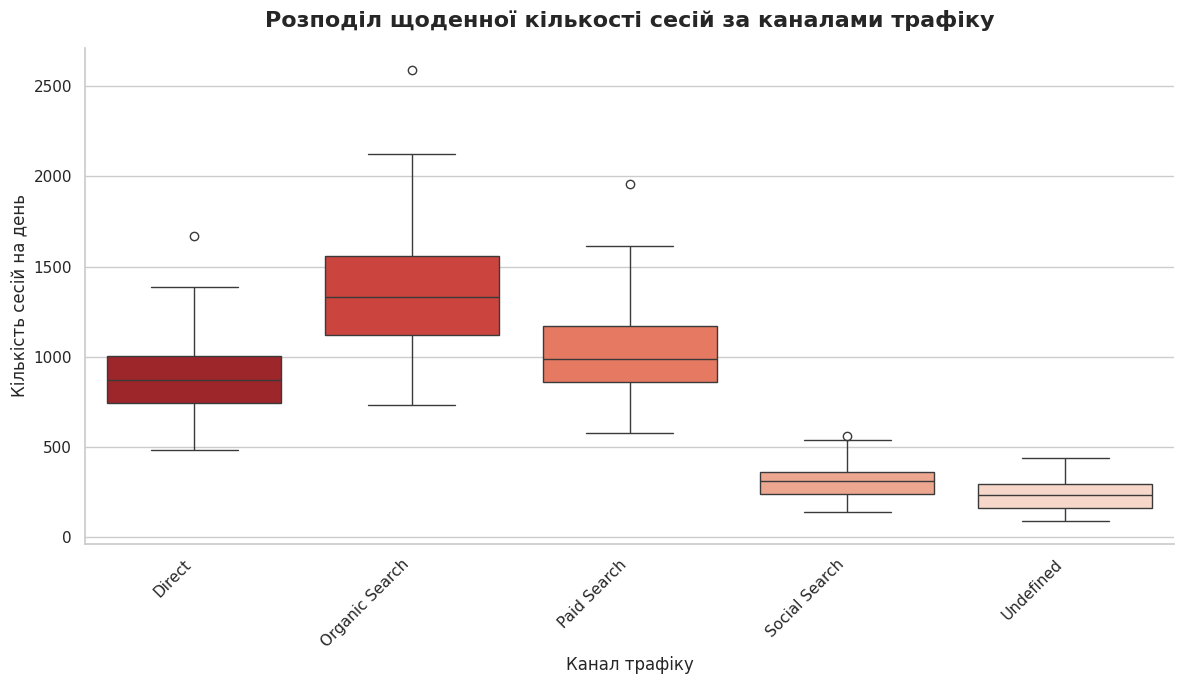

In [82]:
from scipy.stats import shapiro, kruskal

# Агрегуємо щоденну кількість унікальних сесій для кожного каналу
daily_sessions_by_channel = df.groupby(['date', 'channel'])['session_id'].nunique().unstack(fill_value=0)

print("📊 Описова статистика щоденної кількості сесій за каналами:")
print(daily_sessions_by_channel.describe().round(2))
print("\n")

# Підготовка даних для статистичного тесту: список Series з даними по кожному каналу
channel_data = [daily_sessions_by_channel[channel] for channel in daily_sessions_by_channel.columns]

# Перевірка на нормальність розподілу (Shapiro-Wilk Test)
# Нульова гіпотеза: дані розподілені нормально.
print("🔍 Перевірка на нормальність розподілу (Shapiro-Wilk Test) для щоденних сесій по каналах:")
for channel, data in zip(daily_sessions_by_channel.columns, channel_data):
    # Shapiro-Wilk вимагає len(data) >= 3 інакше видає помилку, або len(data) <= 5000
    if len(data) > 5000:
        print(f"  Канал '{channel}': Вибірка занадто велика для Shapiro-Wilk (n={len(data)}). Припускаємо ненормальний розподіл.")
        # Можна використати тест D'Agostino-Pearson або Kolmogorov-Smirnov для більших вибірок
    elif len(data) < 3:
        print(f"  Канал '{channel}': Вибірка занадто мала для Shapiro-Wilk (n={len(data)}). Пропускаємо тест.")
    else:
        stat, p = shapiro(data)
        print(f"  Канал '{channel}': p-value = {p:.4e} {'(не нормальний)' if p < 0.05 else '(нормальний)'}")
print("\n")

# Вибір та проведення статистичного тесту
# Оскільки ми порівнюємо більше двох незалежних груп, і щоденні дані лічильників
# часто не є нормально розподіленими, Kruskal-Wallis H-test є підходящим
# непараметричним тестом. Він перевіряє, чи медіани груп однакові.

stat_kruskal, p_val_kruskal = kruskal(*channel_data)

print("⚡ РЕЗУЛЬТАТИ СТАТИСТИЧНОГО ТЕСТУ KRUSKAL-WALLIS:")
print(f"• H-статистика: {stat_kruskal:.4f}")
print(f"• p-value:     {p_val_kruskal:.4e}")

alpha = 0.05
if p_val_kruskal < alpha:
    print(f"\n✅ Висновок: Існують СТАТИСТИЧНО ЗНАЧУЩІ відмінності у медіанній щоденній кількості сесій між каналами трафіку (p-value < {alpha}).")
else:
    print(f"\n❌ Висновок: Статистично значущих відмінностей у медіанній щоденній кількості сесій між каналами трафіку НЕ виявлено (p-value >= {alpha}).")

# Візуалізація розподілу щоденних сесій за каналами
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.boxplot(data=daily_sessions_by_channel, palette="Reds_r")
plt.title('Розподіл щоденної кількості сесій за каналами трафіку', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Канал трафіку', fontsize=12)
plt.ylabel('Кількість сесій на день', fontsize=12)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


In [83]:
from statsmodels.stats.proportion import proportions_ztest

#  Обчислити кількість органічних сесій та загальну кількість сесій для Європи та Америки

# Фільтруємо сесії за каналом 'Organic Search'
organic_sessions_df = df[df['channel'] == 'Organic Search']

# Отримуємо загальну кількість унікальних сесій для кожного континенту
total_sessions_europe = df[df['continent'] == 'Europe']['session_id'].nunique()
total_sessions_americas = df[df['continent'] == 'Americas']['session_id'].nunique()

# Отримуємо кількість унікальних органічних сесій для кожного континенту
organic_sessions_europe = organic_sessions_df[organic_sessions_df['continent'] == 'Europe']['session_id'].nunique()
organic_sessions_americas = organic_sessions_df[organic_sessions_df['continent'] == 'Americas']['session_id'].nunique()

# Підготовка даних для Z-тесту
count = [organic_sessions_europe, organic_sessions_americas]
nobs = [total_sessions_europe, total_sessions_americas]

print(f"Кількість органічних сесій в Європі: {organic_sessions_europe}")
print(f"Загальна кількість сесій в Європі: {total_sessions_europe}")
print(f"Кількість органічних сесій в Америці: {organic_sessions_americas}")
print(f"Загальна кількість сесій в Америці: {total_sessions_americas}")

# Виконати Z-тест для пропорцій

# H0 (нульова гіпотеза): Частка органічних сесій в Європі дорівнює частці в Америці.
# Ha (альтернативна гіпотеза): Частка органічних сесій в Європі відрізняється від частки в Америці.

stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

alpha = 0.05

print(f"\nZ-статистика: {stat:.4f}")
print(f"P-значення: {p_value:.4f}")

if p_value < alpha:
    print(f"\nВисновок: Відхиляємо нульову гіпотезу. Існує статистично значуща різниця в долі сесій з органічним трафіком між Європою та Америкою (p < {alpha}).")
else:
    print(f"\nВисновок: Немає підстав відхиляти нульову гіпотезу. Статистично значущої різниці в долі сесій з органічним трафіком між Європою та Америкою не виявлено (p >= {alpha}).")


Кількість органічних сесій в Європі: 23195
Загальна кількість сесій в Європі: 65135
Кількість органічних сесій в Америці: 68671
Загальна кількість сесій в Америці: 193179

Z-статистика: 0.2895
P-значення: 0.7722

Висновок: Немає підстав відхиляти нульову гіпотезу. Статистично значущої різниці в долі сесій з органічним трафіком між Європою та Америкою не виявлено (p >= 0.05).


## Детальний висновок з аналізу

Проведений аналіз даних про продажі за період з 2020-11-01 по 2021-01-31 виявив ключові закономірності, що впливають на дохід компанії, та визначив основні KPI для подальшої оптимізації:

### Ключові показники ефективності (KPI) за період:
*   **Загальна виручка:** 31 971 731.10 $
*   **Кількість унікальних країн:** 108
*   **Кількість проданих товарів (замовлень):** 33 538
*   **Кількість унікальних сесій:** 349 545

### 1. Загальна динаміка та тенденції
*   Спостерігається виражена тижнева циклічність та значний передсвятковий пік продажів у грудні, після якого йде спад, а потім поступове відновлення. Ця динаміка характерна для продажів загалом, а також у розрізі континентів, пристроїв, каналів та категорій.

### 2. Географічні показники та ринки
*   **United States** є безумовним лідером за кількістю продажів та виручкою. До топ-5 країн також входять India , Canada , United Kingdom та France.
*   **Топ-континенти**: **Americas** генерує найбільший дохід, за ним слідують Asia та Europe.

### 3. Канали трафіку
*   **Organic Search** є найефективнішим каналом за обсягом продажів.


### 4. Поведінка користувачів та ключові KPI
*   **Незареєстровані гості генерують абсолютну більшість щоденного доходу** (приблизно в 5 разів більше, p < 0.001).
*   Зареєстровані користувачі, особливо підписані на розсилку, роблять у 5.2 рази більше замовлень, хоча їхній загальний внесок у дохід менший.
*   71.7% зареєстрованих користувачів верифікували свій email, а 83.1% залишаються підписаними на розсилку, що є високими показниками залученості.

### 5. Продуктові категорії
*    **Sofas & Armchairs** є найприбутковішою категорією, за нею йдуть Chairs, Beds, Bookcases & Shelving Units та Cabinets & Cupboards.


### 6. Пристрої
*   **Домінантні пристрої**: **Desktop** є основним джерелом продажів, а **Mobile** посідає друге місце, повторюючи загальні сезонні тренди.


## Бізнес-рекомендації

1.  **Оптимізація роботи з гостьовими користувачами**: Оскільки незареєстровані користувачі є основним джерелом доходу (з високим AOV), необхідно дослідити їхню поведінку для розробки стратегій утримання та стимулювання до повторних покупок без обов'язкової реєстрації. Розглянути легкі форми реєстрації або гостьові програми лояльності.

2.  **Підвищення AOV зареєстрованих користувачів**: Хоча зареєстровані користувачі демонструють високу частоту покупок, їхній загальний внесок у дохід менший. Рекомендується впровадити програми лояльності, персоналізовані пропозиції та крос-продажі для підвищення їхнього **AOV** та загальної цінності для компанії.

3.  **Фокус на ключових ринках та каналах**: Продовжувати зосереджувати маркетингові зусилля на **United States** та континенті **Americas**, а також розвивати **Organic Search** як найбільш прибутковий канал.

4.  **Ефективне сезонне планування**: Використовувати виявлену сезонність (особливо грудневий пік) для планування маркетингових кампаній, знижок та управління запасами, щоб максимізувати дохід у пікові періоди.

5.  **Стратегії для продуктових категорій**: Продовжувати просування топових категорій (наприклад, **Sofas & Armchairs**). Завдяки помірним кореляціям між продажами категорій, розглянути можливості крос-продажів та формування комплектних пропозицій.

6.  **Адаптація під пристрої**: Підтримувати та розвивати адаптивний дизайн та зручність використання сайту як для **Desktop**, так і для **Mobile** користувачів, оскільки вони є основними джерелами трафіку та продажів.


**Tableau**: https://public.tableau.com/app/profile/kateryna.zdor/viz/ExecutiveSalesTrafficAnalytics2/Dashboard1#1$0